In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.cluster import KMeans
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [2]:
url = "https://raw.githubusercontent.com/Zuckmo/Production-System/refs/heads/main/production_data_processed.csv"
df = pd.read_csv(url)

In [3]:
df.head()

,timestamp,machine_id,machine_type,line_id,shift,operator_id,product_type,temperature,vibration_level,power_consumption,...,machine_age_hours,last_maintenance_hours,oil_level,lubrication_status,units_produced,downtime,ambient_temperature,humidity,noise_level_db,defect_count
0,2025-03-10 08:00:00,M003,Drill,L3,Shift_1_Pagi,OP003,Gear,78.302879,2.043751,23.059855,...,15200.00,0.0167,94.25,Good,1,0,29.31,71.0,94.2,1
1,2025-03-10 08:01:00,M004,Lathe,L1,Shift_1_Pagi,OP003,Shaft,80.877076,2.175590,16.012814,...,6100.00,0.0167,76.45,Good,0,38,26.84,69.1,79.7,0
2,2025-03-10 08:02:00,M001,CNC,L1,Shift_1_Pagi,OP003,Shaft,71.315418,2.154465,15.759164,...,12500.00,0.0167,75.14,Good,0,37,26.50,65.7,86.6,0
3,2025-03-10 08:03:00,M003,Drill,L3,Shift_1_Pagi,OP003,Gear,76.496198,2.245978,16.490268,...,15200.02,0.0334,95.59,Good,0,39,30.70,56.4,73.3,0
4,2025-03-10 08:04:00,M003,Drill,L3,Shift_1_Pagi,OP003,Gear,73.612202,2.097302,18.064286,...,15200.03,0.0501,92.93,Good,0,0,25.23,64.9,79.4,0


In [4]:
df.describe()

,temperature,vibration_level,power_consumption,pressure,material_flow_rate,cycle_time,error_rate,machine_age_hours,last_maintenance_hours,oil_level,units_produced,downtime,ambient_temperature,humidity,noise_level_db,defect_count
count,9873.000000,9867.000000,9843.000000,10081.000000,10081.000000,10081.000000,10081.000000,10081.000000,10081.000000,10081.000000,10081.000000,10081.000000,10081.000000,10081.000000,10081.000000,10081.000000
mean,78.499017,2.527963,18.772308,4.994121,20.021842,120.074919,0.803934,10631.951225,0.272349,64.242848,0.238468,9.091558,27.654941,70.024492,85.441762,0.102073
std,4.636925,1.495988,3.160202,0.393322,1.513087,5.034450,0.093234,3514.446743,0.277939,22.963748,0.426168,15.470506,2.915934,6.417285,8.190876,0.302760
min,61.751166,1.000000,10.000000,3.431040,15.000000,100.000000,0.500000,6100.000000,0.000000,19.850000,0.000000,0.000000,18.300000,46.800000,65.100000,0.000000
25%,75.448803,1.676094,16.777341,4.732040,19.012195,116.647380,0.739148,8301.500000,0.066800,62.820000,0.000000,0.000000,25.380000,65.500000,79.000000,0.000000
50%,78.171483,2.151601,18.461864,4.987765,20.025569,120.078924,0.798763,12503.050000,0.183700,69.150000,0.000000,0.000000,27.230000,70.000000,85.300000,0.000000
75%,80.967829,2.889681,20.377639,5.252237,21.030506,123.531996,0.859955,12545.050000,0.384100,75.940000,0.000000,15.000000,30.040000,74.600000,92.000000,0.000000
max,100.000000,9.488070,34.368410,6.662317,25.143366,142.395421,1.000000,15241.350000,1.853700,97.800000,1.000000,50.000000,36.590000,91.500000,112.200000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10081 entries, 0 to 10080
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   timestamp               10081 non-null  object 
 1   machine_id              10081 non-null  object 
 2   machine_type            10081 non-null  object 
 3   line_id                 10081 non-null  object 
 4   shift                   10081 non-null  object 
 5   operator_id             10081 non-null  object 
 6   product_type            10081 non-null  object 
 7   temperature             9873 non-null   float64
 8   vibration_level         9867 non-null   float64
 9   power_consumption       9843 non-null   float64
 10  pressure                10081 non-null  float64
 11  material_flow_rate      10081 non-null  float64
 12  cycle_time              10081 non-null  float64
 13  error_rate              10081 non-null  float64
 14  machine_age_hours       10081 non-null

#  DATASET DESCRIPTION

##  IDENTITAS
- **machine_id**: Unique identifier for each machine  
  Values: M001, M002, M003, M004  

- **machine_type**: Type of production equipment  
  Values: CNC, Drill, Welder, Conveyor  

- **line_id**: Production line identifier  
  Values: L1, L2, L3  

- **shift**: Work shift during observation  
  Values:  
  - Shift_1_Pagi (06:00–14:00)  
  - Shift_2_Sore (14:00–22:00)  
  - Shift_3_Malam (22:00–06:00)  

- **operator_id**: Operator identifier  
  Values: OP001–OP012  

- **product_type**: Type of product being produced  
  Values: Shaft, Bracket, Housing, Flange, Gear  

---

##  TIME FEATURES
- **hour**: Hour of the day (0–23)  
- **day_of_week**: Day index (0 = Monday, 6 = Sunday)  
- **is_weekend**:  
  - 0 = Weekday  
  - 1 = Weekend  

---

##  SENSOR MESIN
- **temperature**: Machine temperature (°C)  
  Range: 61.75–100.0  
  Note: May contain NaN  

- **vibration_level**: Vibration intensity (g)  
  Range: 1.0–9.49  
  Note: Higher = more mechanical stress, may contain NaN  

- **power_consumption**: Power usage (kW)  
  Range: 10.0–34.37  
  Note: May contain NaN  

- **pressure**: Operating pressure (bar)  
  Range: 3.43–6.66  

- **material_flow_rate**: Material input rate (kg/min)  
  Range: 15.0–25.14  

- **cycle_time**: Time per production cycle (seconds)  
  Range: 100.0–142.4  

- **error_rate**: Normalized error signal (0.5–1.0)  
  Note: 1.0 = maximum detected error  

---

##  KONDISI MESIN
- **machine_age_hours**: Total operating hours  
  Range: 6,100–15,241  

- **last_maintenance_hours**: Time since last maintenance (hours)  
  Range: 0.0–1.85  

- **oil_level**: Lubrication level (%)  
  Range: 19.85–97.8  

- **lubrication_status**:  
  - Good (≥70%)  
  - Low (40–69%)  
  - Critical (<40%)  

---

##  OUTPUT PRODUKSI
- **units_produced**: Units produced per minute  
  Range: 0–3  
  Note: Depends on machine type and downtime  

- **downtime**: Non-operational duration (minutes/hour)  
  Range: 0–50  
  Note: 0 = fully operational  

---

##  LINGKUNGAN
- **ambient_temperature**: Room temperature (°C)  
  Range: 18.3–36.6  

- **humidity**: Relative humidity (%)  
  Range: 46.8–91.5  

- **noise_level_db**: Noise level (dB)  
  Range: 65.1–112.2  

  Typical values:
  - Welder: ~95 dB  
  - Drill: ~88 dB  
  - CNC: ~82 dB  
  - Conveyor: ~75 dB  

In [10]:
cols = ["machine_type", "line_id", "shift", "operator_id", "product_type", "machine_id", "lubrication_status", "defect_count"]

for col in cols:
  print(f"{col} counts:\n{df[col].value_counts()}\n")

machine_type counts:
machine_type
CNC       2742
Drill     2482
Lathe     2430
Welder    2427
Name: count, dtype: int64

line_id counts:
line_id
L1    5172
L3    2482
L2    2427
Name: count, dtype: int64

shift counts:
shift
Shift_1_Pagi     3361
Shift_2_Sore     3360
Shift_3_Malam    3360
Name: count, dtype: int64

operator_id counts:
operator_id
OP007    960
OP012    960
OP008    960
OP004    960
OP005    960
OP001    960
OP009    960
OP003    840
OP010    840
OP002    601
OP011    600
OP006    480
Name: count, dtype: int64

product_type counts:
product_type
Shaft      3728
Bracket    2713
Flange     1299
Gear       1213
Housing    1128
Name: count, dtype: int64

machine_id counts:
machine_id
M001    2742
M003    2482
M004    2430
M002    2427
Name: count, dtype: int64

lubrication_status counts:
lubrication_status
Good        4584
Low         3070
Critical    2427
Name: count, dtype: int64

defect_count counts:
defect_count
0    9052
1    1029
Name: count, dtype: int64



In [11]:
numeric_cols = [
    "temperature",
    "vibration_level",
    "power_consumption",
    "pressure",
    "material_flow_rate",
    "cycle_time",
    "error_rate",
    "machine_age_hours",
    "last_maintenance_hours",
    "oil_level",
    "units_produced",
    "downtime",
    "ambient_temperature",
    "humidity",
    "noise_level_db",
    "defect_count"
]


categorical_cols = [
    "machine_id",
    "machine_type",
    "line_id",
    "shift",
    "operator_id",
    "product_type",
    "lubrication_status"
]

# DATA PREPROCESSING

## Convert timestamp

In [12]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

## check NaN

In [13]:
df.isnull().sum()

,0
timestamp,0
machine_id,0
machine_type,0
line_id,0
shift,0
operator_id,0
product_type,0
temperature,208
vibration_level,214
power_consumption,238


In [14]:
df = df.fillna(df.mean(numeric_only=True))

In [15]:
df.duplicated().sum()

np.int64(0)

## check outliers and fix them

In [16]:
for column in df.select_dtypes(include=['number']).columns:
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)

  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

  if not outliers.empty:
    print(f"column '{column}' : {len(outliers)} outliers found.")
  else:
    print(f"column '{column}' : no outliers found.")

column 'temperature' : 355 outliers found.
column 'vibration_level' : 690 outliers found.
column 'power_consumption' : 432 outliers found.
column 'pressure' : 97 outliers found.
column 'material_flow_rate' : 76 outliers found.
column 'cycle_time' : 62 outliers found.
column 'error_rate' : 23 outliers found.
column 'machine_age_hours' : no outliers found.
column 'last_maintenance_hours' : 505 outliers found.
column 'oil_level' : 2548 outliers found.
column 'units_produced' : 2404 outliers found.
column 'downtime' : 1097 outliers found.
column 'ambient_temperature' : 1 outliers found.
column 'humidity' : 23 outliers found.
column 'noise_level_db' : 1 outliers found.
column 'defect_count' : 1029 outliers found.


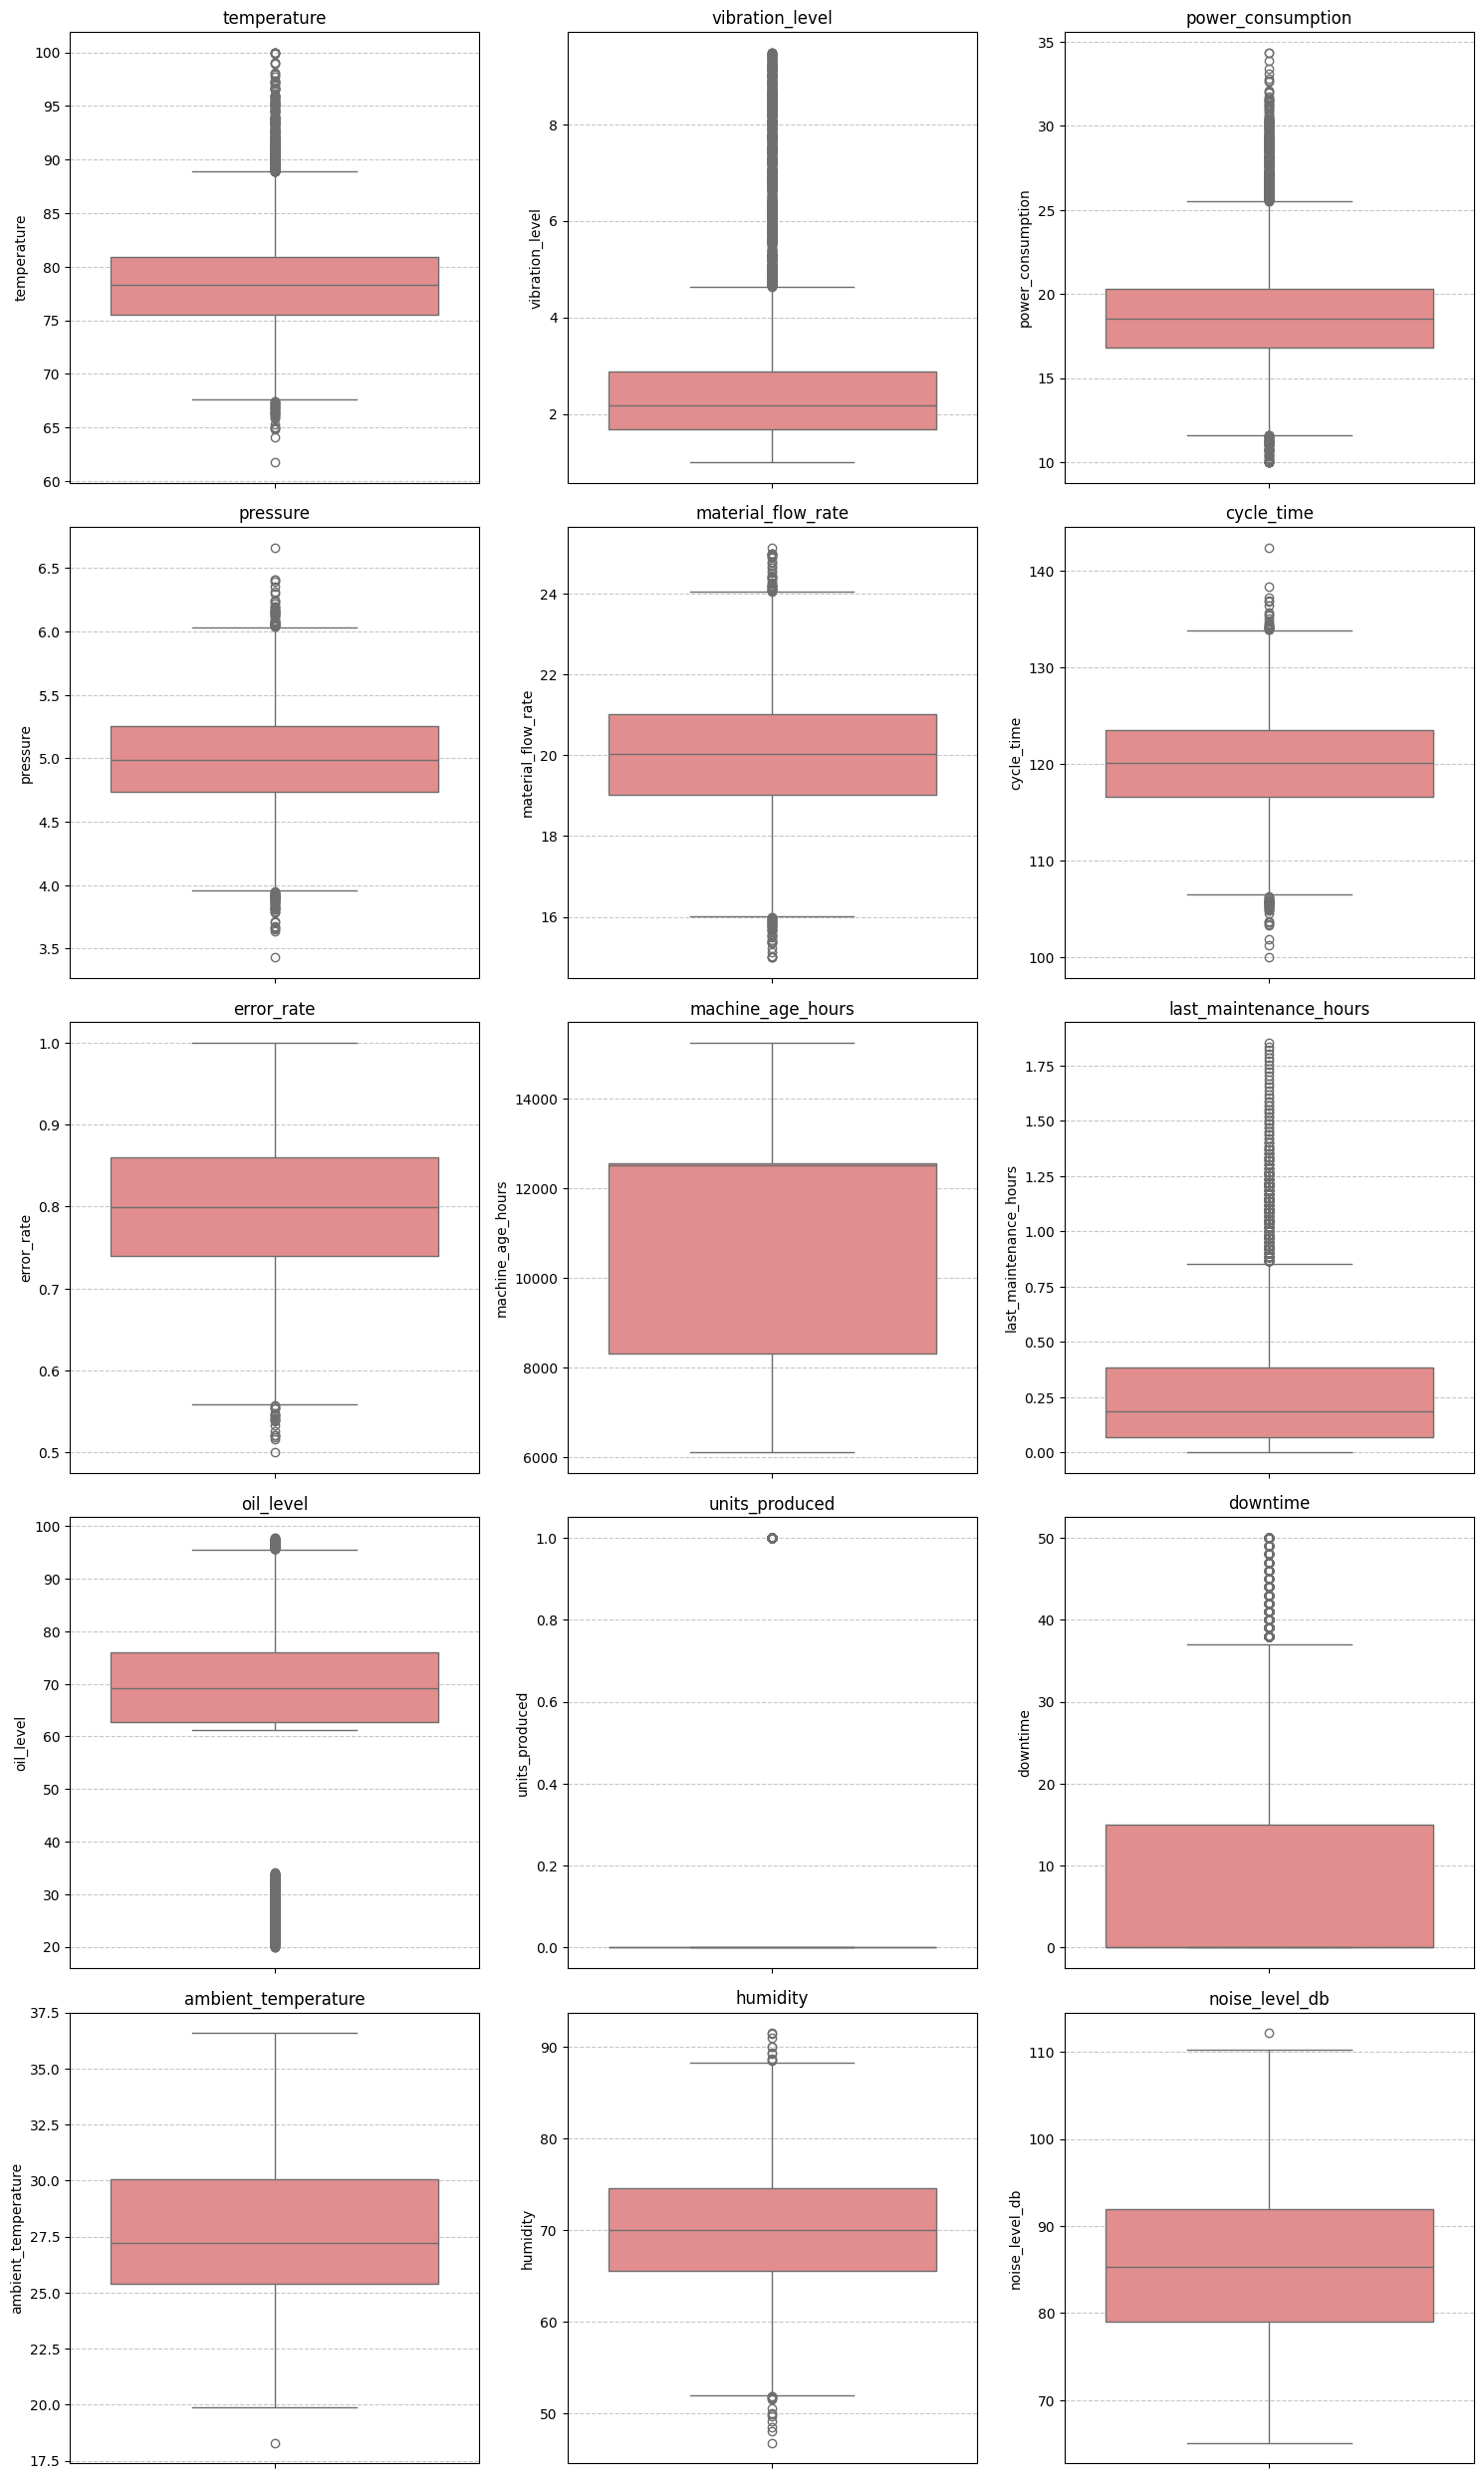

In [19]:
# Visualization of Outliers


# Columns for which to create box plots
columns_for_boxplot =  [ "temperature", "vibration_level", "power_consumption", "pressure", "material_flow_rate", "cycle_time", "error_rate", "machine_age_hours", "last_maintenance_hours", "oil_level", "units_produced", "downtime", "ambient_temperature", "humidity", "noise_level_db"]

n_cols = 3
n_rows = int(np.ceil(len(columns_for_boxplot) / n_cols))

fig, axes = plt.subplots(nrows = n_rows, ncols = n_cols, figsize = (15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(columns_for_boxplot):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'{col}')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Hapus subplot kosong
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

As illustrated in the box plot above, there are numerous outliers. We have decided to retain these data points, as they may be critical indicators—such as signs that the machine requires maintenance or that the temperature has reached an overheating state.

therefore, we utilize Winsorization (also known as percentile capping), a statistical technique used to manage the impact of outliers in a dataset. Instead of completely removing them, this method replaces the extreme values with the nearest values within a predetermined range.

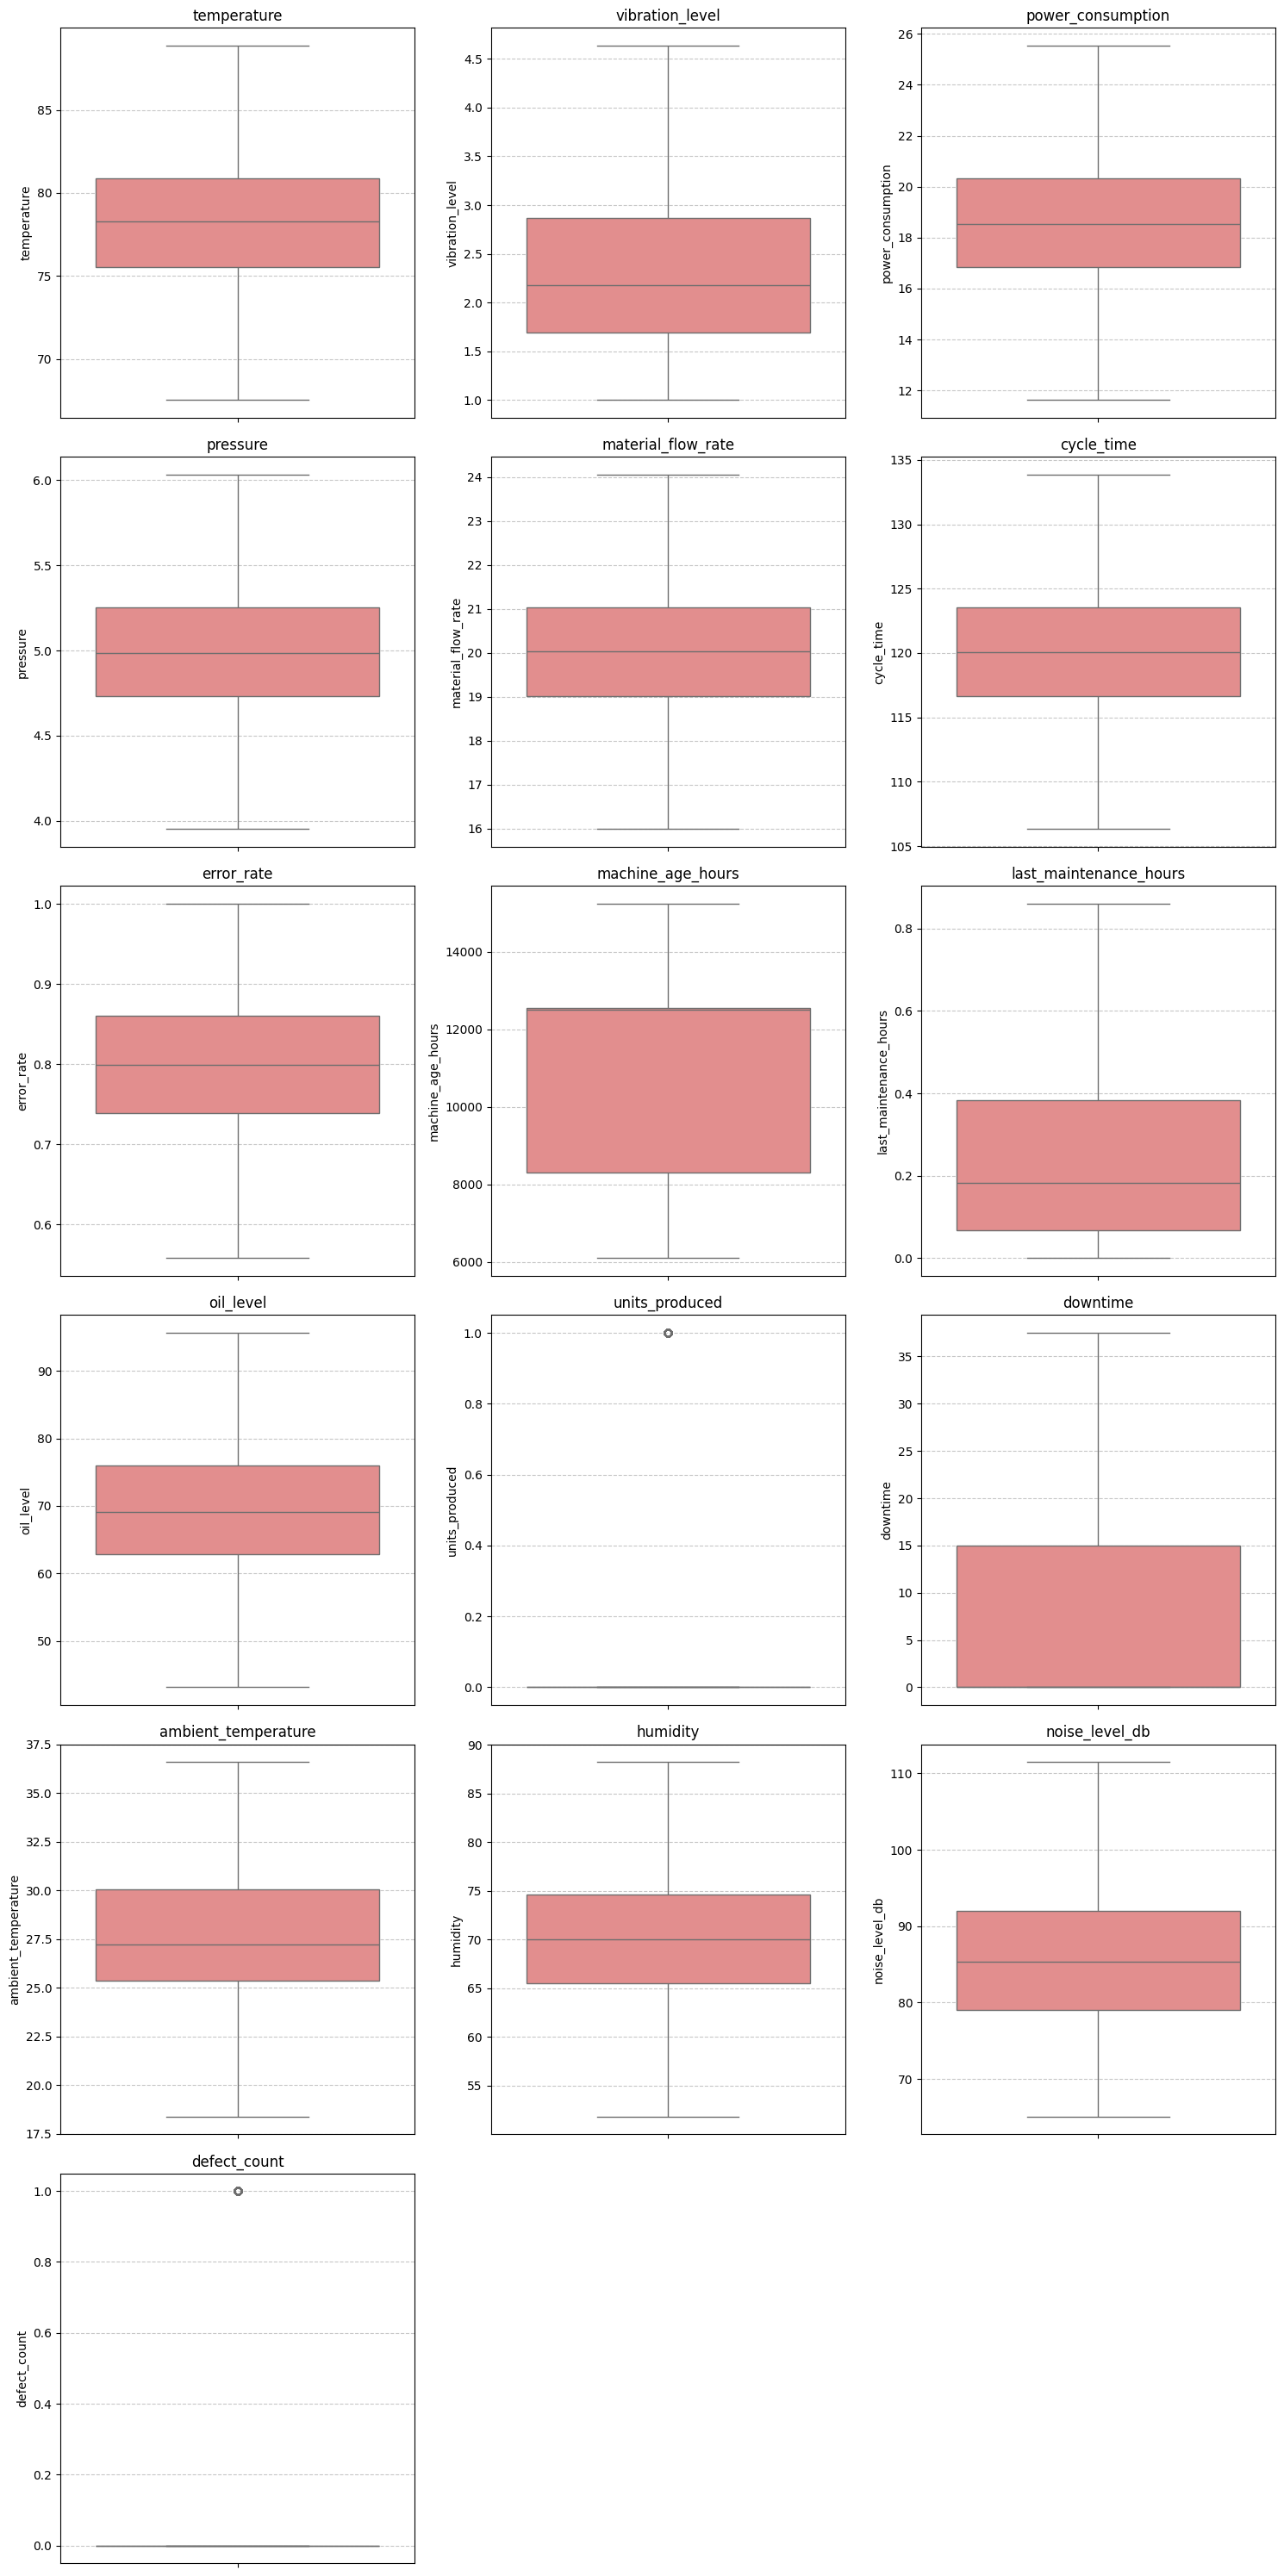

In [20]:
#Capping (Winsorization) method
numerical_cols = [
    "temperature", "vibration_level", "power_consumption", "pressure",
    "material_flow_rate", "cycle_time", "error_rate", "machine_age_hours",
    "last_maintenance_hours", "oil_level", "units_produced", "downtime",
    "ambient_temperature", "humidity", "noise_level_db", "defect_count"
]

for col in numerical_cols:
    # lewati colom unit produced dan defect counts
    if col in ["units_produced", "defect_count"]:
        continue

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower, upper=upper)

# visulaization
# Columns for which to create box plots
columns_for_boxplot =  [ "temperature", "vibration_level", "power_consumption", "pressure", "material_flow_rate", "cycle_time", "error_rate", "machine_age_hours", "last_maintenance_hours", "oil_level", "units_produced", "downtime", "ambient_temperature", "humidity", "noise_level_db", "defect_count"]

n_cols = 3
n_rows = int(np.ceil(len(columns_for_boxplot) / n_cols))

fig, axes = plt.subplots(nrows = n_rows, ncols = n_cols, figsize = (15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(columns_for_boxplot):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'{col}')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Hapus subplot kosong
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## check correlation matrix

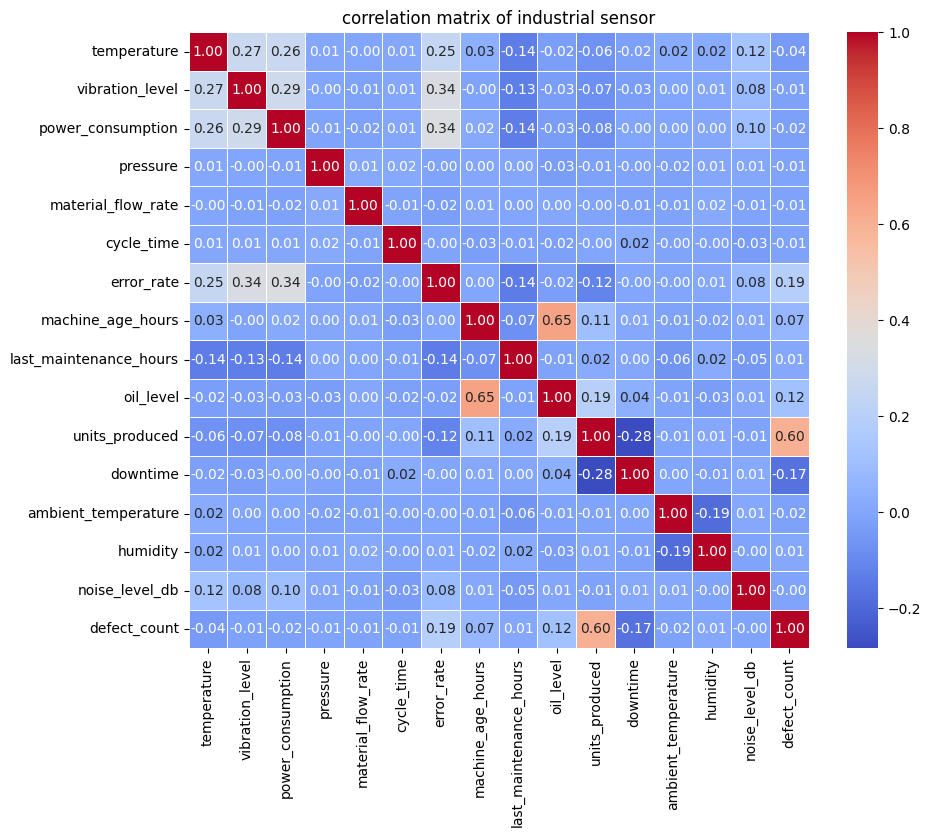

In [21]:
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

plt.title("correlation matrix of industrial sensor")
plt.show()

## correlation matrix interpretation

### 1. strong cor
**machine age hours and oil level**

as machine age increased, the oil lecvel shows a noticable change

this likely reflects increased lunbrication needs or oil degradation over time

### 2. moderate cor
**error rate with:**
- vib level
- power consumption
- temperature

these are associated with error rate

### 3. weak cor
- pressure
- material flow rate
- cycle time

these variable show little to or no linear relationship


## menghitung OEE

$$OEE = \text{Availability} \times \text{Performance} \times \text{Quality}$$

$$\text{Availability} = \frac{\text{Run Time}}{\text{Planned Production Time}}$$

$$\text{Performance} = \frac{\text{Ideal Cycle Time} \times \text{Total Count}}{\text{Run Time}}$$


$$\text{Quality} = \frac{\text{Good Count}}{\text{Total Count}}$$

## availability

In [22]:
total_units_produced = df["units_produced"].sum()

print(f"total units produced : {total_units_produced}" , "\n" )

rows_with_downtime = df[df["downtime"] > 0].shape[0]
print(f"number of rows with downtime (downtime > 0) : {rows_with_downtime}", "\n")

min_timestamp = df["timestamp"].min()
max_timestamp = df["timestamp"].max()

total_duration = (max_timestamp - min_timestamp).total_seconds() / 3600


print(f"The earliest timestamp is: {min_timestamp}")
print(f"The latest timestamp is: {max_timestamp}")
print(f"The total duration covered by the timestamps is: {total_duration}", "\n")


total units produced : 2404 

number of rows with downtime (downtime > 0) : 3204 

The earliest timestamp is: 2025-03-10 08:00:00
The latest timestamp is: 2025-03-17 08:00:00
The total duration covered by the timestamps is: 168.0 



In [23]:
availability = (10080 - 3204) / 10080
print(f"The availability of the machine is: {availability}")

The availability of the machine is: 0.6821428571428572


## performance
because idel cycle time is not decided, we tried to find the idel cycle time by seeing the time that produce items a lot at average time

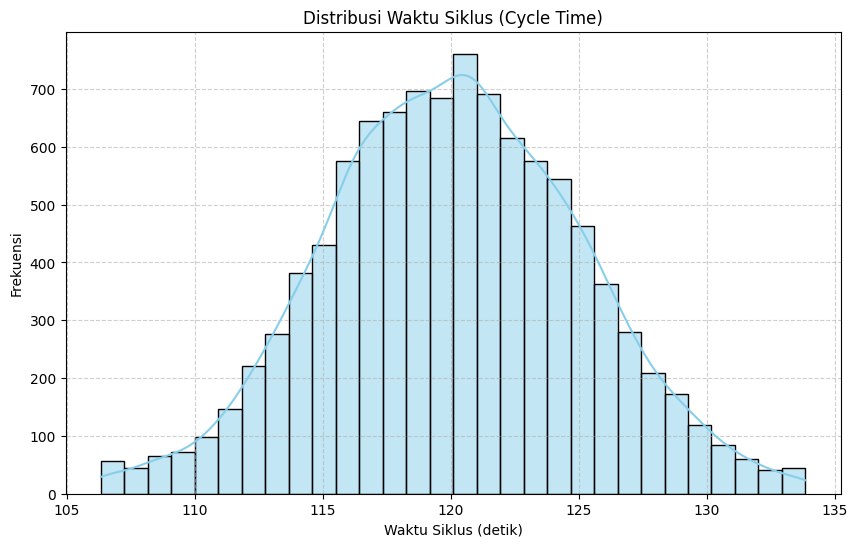

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(df['cycle_time'], kde=True, bins=30, color='skyblue')
plt.title('Distribusi Waktu Siklus (Cycle Time)')
plt.xlabel('Waktu Siklus (detik)')
plt.ylabel('Frekuensi')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

selanjutnya kita lihat hubungan cycle time dengan defect count dan error rate

In [26]:
# Group cycle_time into bins to see the trend
df['cycle_time_bin'] = pd.cut(df['cycle_time'], bins=5, precision=0)

# Calculate average defect_count and error_rate per cycle_time_bin
cycle_time_defect_analysis = df.groupby('cycle_time_bin').agg(
    avg_defect_count=('defect_count', 'mean'),
    avg_error_rate=('error_rate', 'mean'),
    total_units_produced=('units_produced', 'sum')
).reset_index()

print("Analisis Waktu Siklus terhadap Cacat dan Tingkat Kesalahan:")
print(cycle_time_defect_analysis)


Analisis Waktu Siklus terhadap Cacat dan Tingkat Kesalahan:
   cycle_time_bin  avg_defect_count  avg_error_rate  total_units_produced
0  (106.0, 112.0]          0.097107        0.807994                   110
1  (112.0, 117.0]          0.107948        0.803722                   608
2  (117.0, 123.0]          0.105084        0.802552                  1004
3  (123.0, 128.0]          0.090722        0.807272                   548
4  (128.0, 134.0]          0.107486        0.797387                   134


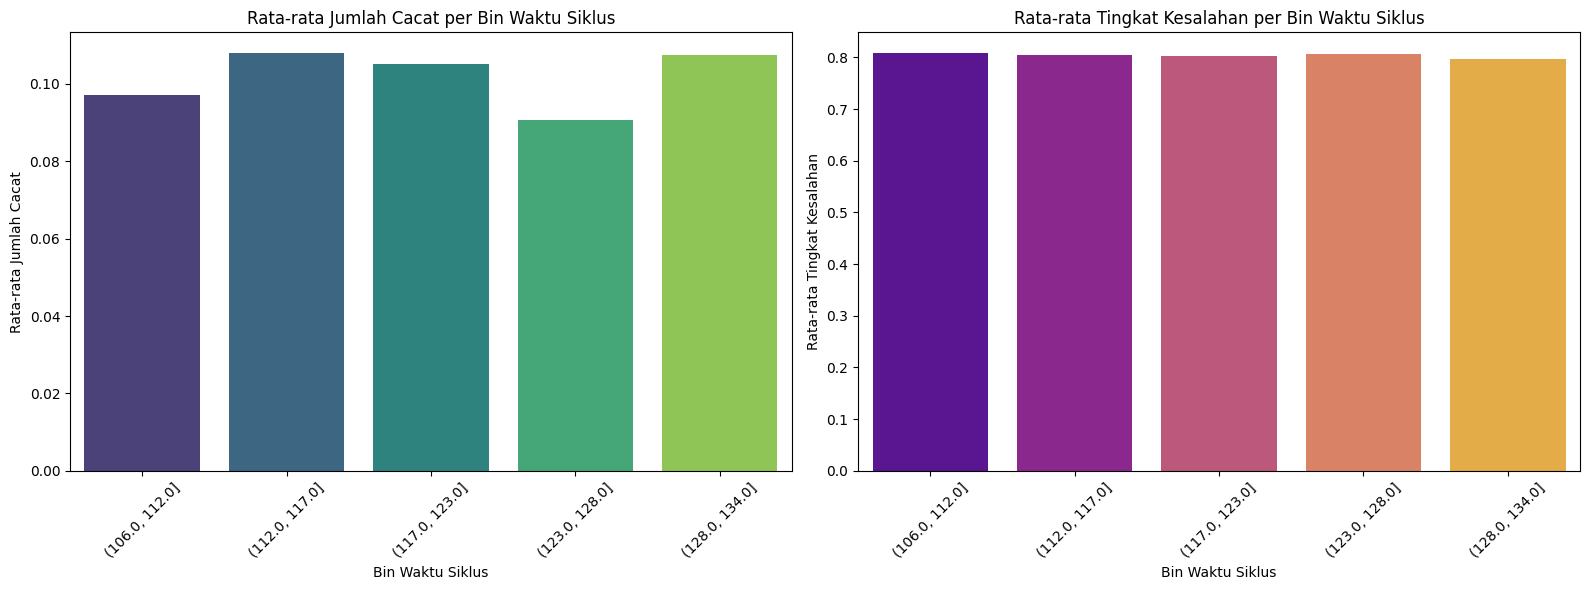

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='cycle_time_bin', y='avg_defect_count', data=cycle_time_defect_analysis, ax=axes[0], palette='viridis')
axes[0].set_title('Rata-rata Jumlah Cacat per Bin Waktu Siklus')
axes[0].set_xlabel('Bin Waktu Siklus')
axes[0].set_ylabel('Rata-rata Jumlah Cacat')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x='cycle_time_bin', y='avg_error_rate', data=cycle_time_defect_analysis, ax=axes[1], palette='plasma')
axes[1].set_title('Rata-rata Tingkat Kesalahan per Bin Waktu Siklus')
axes[1].set_xlabel('Bin Waktu Siklus')
axes[1].set_ylabel('Rata-rata Tingkat Kesalahan')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

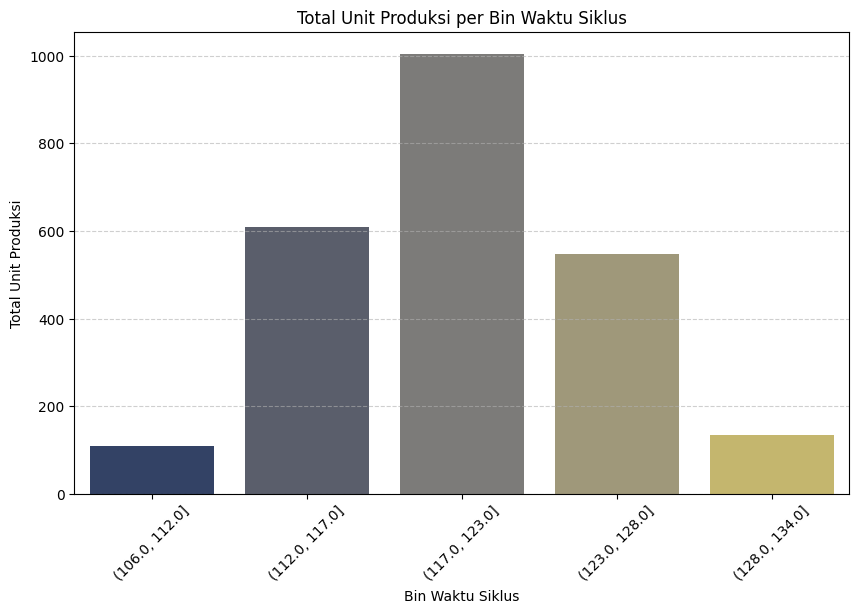

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(x='cycle_time_bin', y='total_units_produced', data=cycle_time_defect_analysis, palette='cividis')
plt.title('Total Unit Produksi per Bin Waktu Siklus')
plt.xlabel('Bin Waktu Siklus')
plt.ylabel('Total Unit Produksi')
plt.tick_params(axis='x', rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Optimal Cycle Time:

The cycle time range of (117.0, 123.0] seconds appears to be the most optimal, yielding the highest total units produced (1004 units)

In [29]:
performance = (120 * total_units_produced) / (10080 - 3204)
print(f"The performance of the machine is: {performance}")

The performance of the machine is: 41.954624781849915


## Quality

In [34]:
total_defect_count = df["defect_count"].sum()
print(f"total defect count : {total_defect_count}", "\n")

good_count = total_units_produced - total_defect_count
print(f"total good count : {good_count}", "\n")

quality = good_count / total_units_produced
print(f"the quality of the machine is: {quality}")

total defect count : 1029 

total good count : 1375 

the quality of the machine is: 0.5719633943427621


## OEE

In [35]:
OEE = availability * performance * quality
print(f"the OEE of the machine is: {OEE}")

the OEE of the machine is: 16.36904761904762


### Average cycle time per machine / shift / line

In [38]:
avg_cycle_time_per_machine = df.groupby("machine_id")["cycle_time"].mean()
print("average Cycle time per Machine", avg_cycle_time_per_machine, "\n")

avg_cycle_time_per_shift = df.groupby("shift")["cycle_time"].mean()
print("average Cycle time per Shift", avg_cycle_time_per_shift, "\n")

avg_cycle_time_per_line = df.groupby("line_id")["cycle_time"].mean()
print("average Cycle time per Line", avg_cycle_time_per_line, "\n")



average Cycle time per Machine machine_id
M001    120.226450
M002    120.070932
M003    119.757787
M004    120.239208
Name: cycle_time, dtype: float64 

average Cycle time per Shift shift
Shift_1_Pagi     120.108519
Shift_2_Sore     120.030276
Shift_3_Malam    120.091286
Name: cycle_time, dtype: float64 

average Cycle time per Line line_id
L1    120.232444
L2    120.070932
L3    119.757787
Name: cycle_time, dtype: float64 



It appears that the average cycle times are remarkably consistent across all machines, shifts, and production lines, hovering around 120 seconds. This suggests a very stable or uniform production process in terms of cycle duration.

### Total downtime and frequency per machine

In [39]:
total_downtime_per_machine = df.groupby("machine_id")["downtime"].sum()

downtime_frequency_per_machine = df.groupby("machine_id")["downtime"].apply(lambda x: (x>0).sum())

print("total downtime per machine", total_downtime_per_machine, "\n")
print("downtime frequency per machine", downtime_frequency_per_machine, "\n")

total downtime per machine machine_id
M001    25861.5
M002    17725.5
M003    20684.5
M004    21486.0
Name: downtime, dtype: float64 

downtime frequency per machine machine_id
M001    960
M002    657
M003    789
M004    798
Name: downtime, dtype: int64 



From these results, it appears that Machine M001 has both the highest total downtime and the highest frequency of downtime occurrences, suggesting it might be the most problematic machine in terms of operational availability.

In [40]:
downtime_per_shift = df.groupby("shift")["downtime"].sum()
print("total downtime per shift", downtime_per_shift, "\n")

total downtime per shift shift
Shift_1_Pagi     28722.0
Shift_2_Sore     28660.5
Shift_3_Malam    28375.0
Name: downtime, dtype: float64 



In [41]:
error_per_operator = df.groupby("operator_id")["error_rate"].mean()
print("average error rate per operator", error_per_operator, "\n")

average error rate per operator operator_id
OP001    0.802664
OP002    0.803100
OP003    0.805031
OP004    0.801209
OP005    0.811312
OP006    0.808157
OP007    0.800247
OP008    0.800158
OP009    0.809003
OP010    0.806376
OP011    0.803330
OP012    0.799124
Name: error_rate, dtype: float64 



In [42]:
error_rate_per_product_type = df.groupby('product_type')['error_rate'].sum()
print("Total Downtime per Product Type (minutes/hour):\n", error_rate_per_product_type)

Total Downtime per Product Type (minutes/hour):
 product_type
Bracket    2184.519584
Flange     1047.356061
Gear        970.914291
Housing     904.561600
Shaft      2997.576081
Name: error_rate, dtype: float64


# CLustering for Machine Conditions

In [45]:
clustering_features = [
    'temperature', 'vibration_level', 'power_consumption', 'pressure',
    'oil_level', 'machine_age_hours', 'error_rate', 'noise_level_db'
]
df_clustering = df[clustering_features]

print(df_clustering.head())

   temperature  vibration_level  power_consumption  pressure  oil_level  \
0    78.302879         2.043751          23.059855  5.088076      94.25   
1    80.877076         2.175590          16.012814  5.412956      76.45   
2    71.315418         2.154465          15.759164  5.769405      75.14   
3    76.496198         2.245978          16.490268  4.618784      95.59   
4    73.612202         2.097302          18.064286  5.431250      92.93   

   machine_age_hours  error_rate  noise_level_db  
0           15200.00    0.883246            94.2  
1            6100.00    0.777073            79.7  
2           12500.00    0.757374            86.6  
3           15200.02    0.796481            73.3  
4           15200.03    0.813361            79.4  


In [48]:
scaler = StandardScaler()
df_clustering_scaled = scaler.fit_transform(df_clustering)

df_scaled_df = pd.DataFrame(df_clustering_scaled, columns=clustering_features)
df_scaled_df.head()

,temperature,vibration_level,power_consumption,pressure,oil_level,machine_age_hours,error_rate,noise_level_db
0,-0.023864,-0.326322,1.528198,0.241042,1.556422,1.299856,0.851417,1.069358
1,0.576354,-0.194484,-0.935811,1.074402,0.495663,-1.289584,-0.289024,-0.701040
2,-1.653111,-0.215608,-1.024500,1.988742,0.417596,0.531561,-0.500615,0.141425
3,-0.445123,-0.124096,-0.768869,-0.962753,1.636277,1.299862,-0.080556,-1.482458
4,-1.117576,-0.272771,-0.218511,1.121329,1.477759,1.299865,0.100759,-0.737669


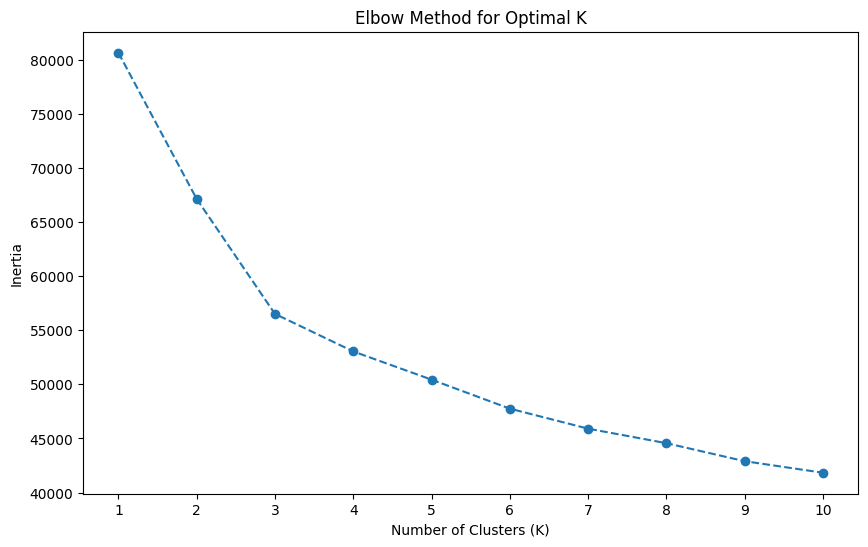

In [51]:
inertia = []

K_range = range(1,11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_clustering_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10,6))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.title('Elbow Method for Optimal K')
plt.show()

#### evaluate again by comparing with other method evaluation

k=2: silhoutte=0.1732, Davies-Bouldin=2.1213
k=3: silhoutte=0.2002, Davies-Bouldin=1.6626
k=4: silhoutte=0.1570, Davies-Bouldin=1.9379
k=5: silhoutte=0.1379, Davies-Bouldin=1.9690
k=6: silhoutte=0.1235, Davies-Bouldin=2.1106
k=7: silhoutte=0.1222, Davies-Bouldin=2.0574
k=8: silhoutte=0.1174, Davies-Bouldin=1.9887
k=9: silhoutte=0.1174, Davies-Bouldin=1.9773




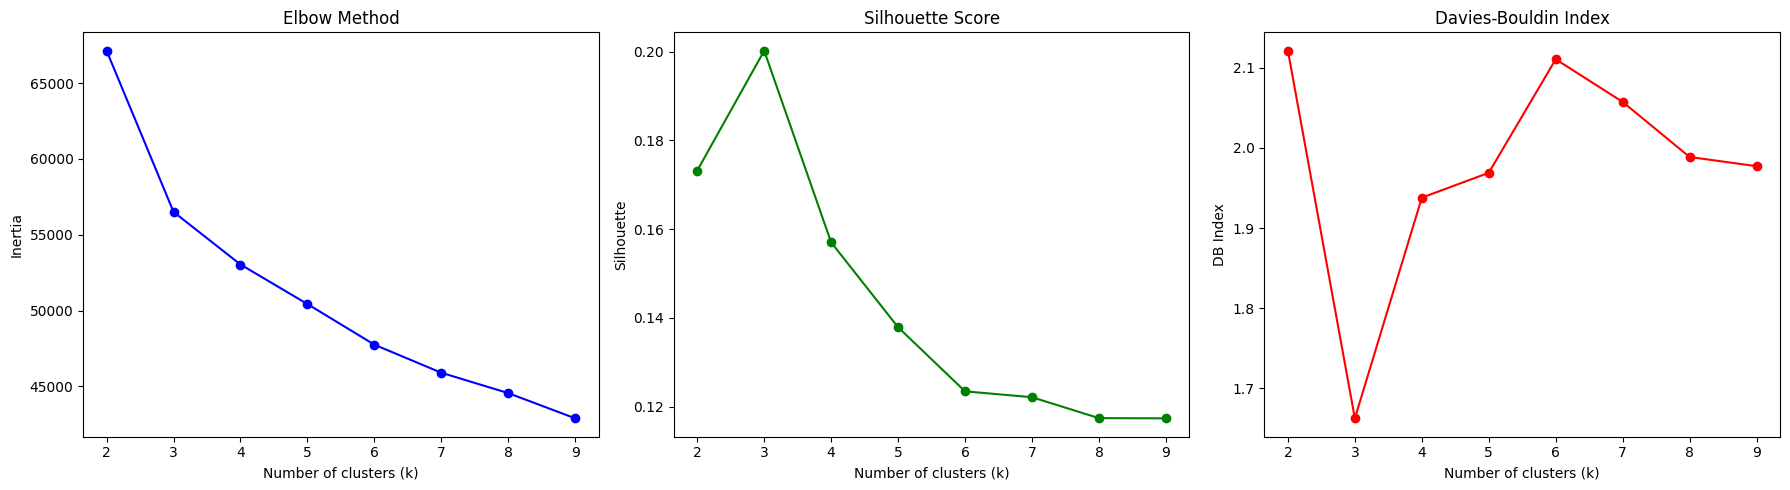

In [57]:
scores = []

for k in range(2, 10):
  kmeans = KMeans(n_clusters=k, random_state=42)
  labels = kmeans.fit_predict(df_clustering_scaled)

  sil = silhouette_score(df_clustering_scaled, labels)
  db = davies_bouldin_score(df_clustering_scaled, labels)

  scores.append((k, sil, db))

for k, sil, db in scores:
  print(f"k={k}: silhoutte={sil:.4f}, Davies-Bouldin={db:.4f}")

print("\n")

k_range = range(2, 10)
inertia_list = []
silhoutte_list = []
db_list = []

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42)
  labels = kmeans.fit_predict(df_clustering_scaled)

  #elbow
  inertia_list.append(kmeans.inertia_)

  #silhoutte
  silhoutte_list.append(silhouette_score(df_clustering_scaled, labels))

  #Davies Bouldin
  db_list.append(davies_bouldin_score(df_clustering_scaled, labels))

# Plot semua
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Elbow
axes[0].plot(k_range, inertia_list, 'o-', color='blue')
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

# Silhouette
axes[1].plot(k_range, silhoutte_list, 'o-', color='green')
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette")

# Davies-Bouldin
axes[2].plot(k_range, db_list, 'o-', color='red')
axes[2].set_title("Davies-Bouldin Index")
axes[2].set_xlabel("Number of clusters (k)")
axes[2].set_ylabel("DB Index")

plt.tight_layout()
plt.show()

## Apply KMeans Clustering

In [58]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

#fit the KMeans to the scaled data and get cluster labels
cluster_labels = kmeans.fit_predict(df_clustering_scaled)

#add the cluster labels to the original dataframe
df['cluster_efficiency_machine'] = cluster_labels

df[['cluster_efficiency_machine']+ clustering_features].head()

,cluster_efficiency_machine,temperature,vibration_level,power_consumption,pressure,oil_level,machine_age_hours,error_rate,noise_level_db
0,2,78.302879,2.043751,23.059855,5.088076,94.25,15200.00,0.883246,94.2
1,1,80.877076,2.175590,16.012814,5.412956,76.45,6100.00,0.777073,79.7
2,2,71.315418,2.154465,15.759164,5.769405,75.14,12500.00,0.757374,86.6
3,2,76.496198,2.245978,16.490268,4.618784,95.59,15200.02,0.796481,73.3
4,2,73.612202,2.097302,18.064286,5.431250,92.93,15200.03,0.813361,79.4


In [60]:
cluster_centroids = df.groupby('cluster_efficiency_machine')[clustering_features].mean()
print("clustering centroids each segment:", cluster_centroids)

clustering centroids each segment:                             temperature  vibration_level  power_consumption  \
cluster_efficiency_machine                                                    
0                             86.351614         4.448683          24.085731   
1                             77.685526         2.218205          18.275542   
2                             77.956600         2.218388          18.313719   

                            pressure  oil_level  machine_age_hours  \
cluster_efficiency_machine                                           
0                           5.001075  66.523834       10768.386880   
1                           4.991546  56.407457        7212.705348   
2                           4.995535  79.423788       13838.733515   

                            error_rate  noise_level_db  
cluster_efficiency_machine                              
0                             0.981396       91.172595  
1                             0.791065       85

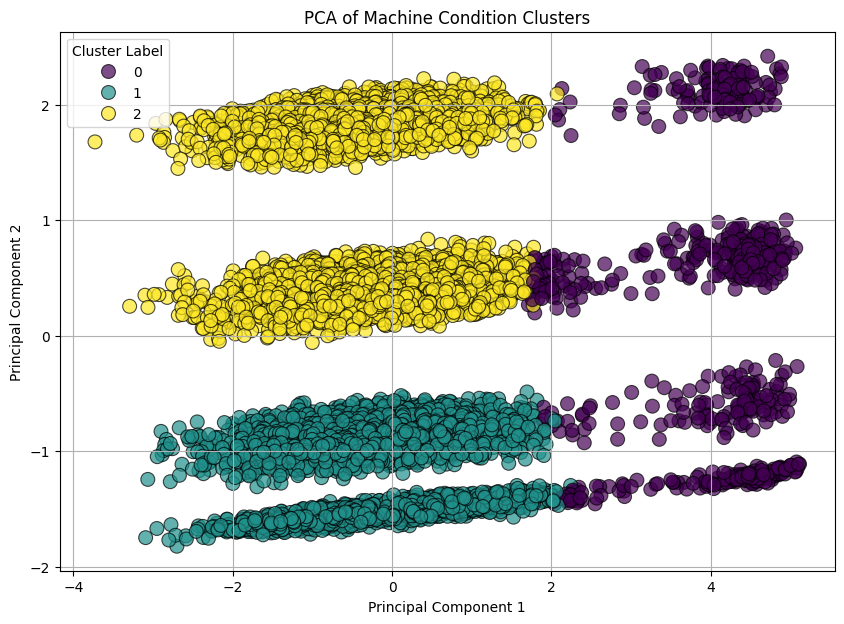

In [63]:
# Initialize PCA with 2 components
pca = PCA(n_components=2, random_state=42)

# Apply PCA to the scaled data
pca_components = pca.fit_transform(df_clustering_scaled)

# Create a DataFrame for PCA components
df_pca = pd.DataFrame(data=pca_components, columns=['PCA1', 'PCA2'])

# Add the cluster labels to the PCA DataFrame for plotting
df_pca['cluster_efficiency_machine'] = df['cluster_efficiency_machine']

# Visualize the clusters using a scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PCA1', y='PCA2', hue='cluster_efficiency_machine', data=df_pca,
    palette='viridis', s=100, alpha=0.7, edgecolor='k'
)
plt.title('PCA of Machine Condition Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster Label')
plt.grid(True)
plt.show()

In [64]:
print("Characteristics of Cluster 0 (Centroid Values):")
print(cluster_centroids.loc[0])


print("\n")
print("Characteristics of Cluster 1 (Centroid Values):")
print(cluster_centroids.loc[1])

print("\n")
print("Characteristics of Cluster 2 (Centroid Values):")
print(cluster_centroids.loc[2])

Characteristics of Cluster 0 (Centroid Values):
temperature             86.351614
vibration_level          4.448683
power_consumption       24.085731
pressure                 5.001075
oil_level               66.523834
machine_age_hours    10768.386880
error_rate               0.981396
noise_level_db          91.172595
Name: 0, dtype: float64


Characteristics of Cluster 1 (Centroid Values):
temperature            77.685526
vibration_level         2.218205
power_consumption      18.275542
pressure                4.991546
oil_level              56.407457
machine_age_hours    7212.705348
error_rate              0.791065
noise_level_db         85.035409
Name: 1, dtype: float64


Characteristics of Cluster 2 (Centroid Values):
temperature             77.956600
vibration_level          2.218388
power_consumption       18.313719
pressure                 4.995535
oil_level               79.423788
machine_age_hours    13838.733515
error_rate               0.790990
noise_level_db          85.011

In [65]:
# Filter the original DataFrame for Cluster 0
df_cluster_0 = df[df['cluster_efficiency_machine'] == 0]
df_cluster_0.head()


,timestamp,machine_id,machine_type,line_id,shift,operator_id,product_type,temperature,vibration_level,power_consumption,...,oil_level,lubrication_status,units_produced,downtime,ambient_temperature,humidity,noise_level_db,defect_count,cycle_time_bin,cluster_efficiency_machine
5,2025-03-10 08:05:00,M004,Lathe,L1,Shift_1_Pagi,OP003,Shaft,86.820317,4.636427,20.040572,...,71.68,Good,0,0.0,28.31,73.6,94.9,0,"(117.0, 123.0]",0
6,2025-03-10 08:06:00,M001,CNC,L1,Shift_1_Pagi,OP003,Shaft,88.885607,4.636427,25.540465,...,71.09,Good,0,0.0,27.02,66.1,103.6,0,"(117.0, 123.0]",0
11,2025-03-10 08:11:00,M003,Drill,L3,Shift_1_Pagi,OP003,Gear,86.600674,4.636427,25.540465,...,95.62,Good,0,0.0,26.93,64.8,80.2,0,"(117.0, 123.0]",0
40,2025-03-10 08:40:00,M003,Drill,L3,Shift_1_Pagi,OP003,Gear,83.945857,4.636427,24.081206,...,92.70,Good,0,0.0,25.02,54.6,83.5,0,"(117.0, 123.0]",0
44,2025-03-10 08:44:00,M004,Lathe,L1,Shift_1_Pagi,OP003,Shaft,88.242884,2.527963,23.257803,...,72.26,Good,0,37.5,29.34,54.5,86.2,0,"(112.0, 117.0]",0


In [66]:
# Filter the original DataFrame for Cluster 1
df_cluster_1 = df[df['cluster_efficiency_machine'] == 1]
df_cluster_1.head()


,timestamp,machine_id,machine_type,line_id,shift,operator_id,product_type,temperature,vibration_level,power_consumption,...,oil_level,lubrication_status,units_produced,downtime,ambient_temperature,humidity,noise_level_db,defect_count,cycle_time_bin,cluster_efficiency_machine
1,2025-03-10 08:01:00,M004,Lathe,L1,Shift_1_Pagi,OP003,Shaft,80.877076,2.175590,16.012814,...,76.45,Good,0,37.5,26.84,69.1,79.7,0,"(123.0, 128.0]",1
9,2025-03-10 08:09:00,M002,Welder,L2,Shift_1_Pagi,OP003,Housing,76.421380,1.710740,17.414629,...,43.14,Critical,0,0.0,24.91,64.2,96.1,0,"(117.0, 123.0]",1
14,2025-03-10 08:14:00,M004,Lathe,L1,Shift_1_Pagi,OP003,Shaft,75.835848,1.736215,21.866719,...,71.83,Good,1,0.0,25.55,61.2,95.2,1,"(106.0, 112.0]",1
16,2025-03-10 08:16:00,M004,Lathe,L1,Shift_1_Pagi,OP003,Shaft,76.897249,1.962448,17.976970,...,72.56,Good,0,0.0,25.38,68.8,94.6,0,"(123.0, 128.0]",1
17,2025-03-10 08:17:00,M004,Lathe,L1,Shift_1_Pagi,OP003,Shaft,73.925736,2.254065,20.061320,...,73.88,Good,0,0.0,30.26,68.2,95.1,0,"(117.0, 123.0]",1


In [67]:
# Filter the original DataFrame for Cluster 2
df_cluster_2 = df[df['cluster_efficiency_machine'] == 2]
df_cluster_2.head()

,timestamp,machine_id,machine_type,line_id,shift,operator_id,product_type,temperature,vibration_level,power_consumption,...,oil_level,lubrication_status,units_produced,downtime,ambient_temperature,humidity,noise_level_db,defect_count,cycle_time_bin,cluster_efficiency_machine
0,2025-03-10 08:00:00,M003,Drill,L3,Shift_1_Pagi,OP003,Gear,78.302879,2.043751,23.059855,...,94.25,Good,1,0.0,29.31,71.0,94.2,1,"(117.0, 123.0]",2
2,2025-03-10 08:02:00,M001,CNC,L1,Shift_1_Pagi,OP003,Shaft,71.315418,2.154465,15.759164,...,75.14,Good,0,37.0,26.50,65.7,86.6,0,"(117.0, 123.0]",2
3,2025-03-10 08:03:00,M003,Drill,L3,Shift_1_Pagi,OP003,Gear,76.496198,2.245978,16.490268,...,95.59,Good,0,37.5,30.70,56.4,73.3,0,"(117.0, 123.0]",2
4,2025-03-10 08:04:00,M003,Drill,L3,Shift_1_Pagi,OP003,Gear,73.612202,2.097302,18.064286,...,92.93,Good,0,0.0,25.23,64.9,79.4,0,"(112.0, 117.0]",2
7,2025-03-10 08:07:00,M001,CNC,L1,Shift_1_Pagi,OP003,Shaft,70.505322,1.592745,21.387094,...,75.94,Good,0,0.0,25.72,63.1,83.9,0,"(123.0, 128.0]",2


## Cluster Characteristics

Based on the K-Means clustering analysis with an optimal number of 3 clusters, the machine operational data has been segmented into distinct groups, each exhibiting unique characteristics regarding their sensor readings and operational state.

### Characteristics of Each Machine Condition Segment:

*   **Cluster 0 (Degraded/Critical Condition)**:
    *   **Description**: This segment represents machines in a severely degraded or critical operational state. They exhibit significantly elevated average sensor readings across several key parameters.
    *   **Key Centroid Values**: High `temperature` (86.35°C), significantly high `vibration_level` (4.45 g), high `power_consumption` (24.09 kW), a very high `error_rate` (0.98), and elevated `noise_level_db` (91.17 dB). The `oil_level` is borderline (66.52%). These machines are typically older, with an average `machine_age_hours` of 10768.39.
    *   **Overall Insight**: This cluster clearly indicates machines under severe stress or experiencing malfunctions, requiring immediate attention.

*   **Cluster 1 (Moderate Condition with Low Oil)**:
    *   **Description**: This segment comprises relatively younger machines that generally show moderate or typical sensor readings across most parameters, but with a significant concern regarding lubrication.
    *   **Key Centroid Values**: Moderate `temperature` (77.69°C), `vibration_level` (2.22 g), `power_consumption` (18.28 kW), `error_rate` (0.79), and `noise_level_db` (85.04 dB). A crucial characteristic is their consistently low average `oil_level` (56.41%), placing them in the 'Low' lubrication status. These are younger machines, averaging 7212.71 `machine_age_hours`.
    *   **Overall Insight**: These machines are at risk of accelerated wear or future performance issues due to insufficient lubrication, despite other parameters appearing stable.

*   **Cluster 2 (Older, Stable, and Healthy)**:
    *   **Description**: This segment represents older machines that are remarkably operating in a stable and healthy condition, demonstrating effective maintenance practices.
    *   **Key Centroid Values**: Moderate `temperature` (77.96°C), `vibration_level` (2.22 g), `power_consumption` (18.31 kW), `error_rate` (0.79), and `noise_level_db` (85.01 dB), all within acceptable ranges. Crucially, their `oil_level` is high and healthy (79.42%), indicating 'Good' lubrication status. These are the oldest machines, with an average `machine_age_hours` of 13838.73.
    *   **Overall Insight**: This cluster signifies well-maintained, high-performing machines that are functioning effectively even after extensive operational hours.

    In conclusion, this clustering analysis provides a powerful framework for segmenting machines based on their operational health.

# Shift Level Clustering

In [71]:
# Create a 'date' column from the timestamp
df['date'] = df['timestamp'].dt.date

# Create a unique shift instance ID
df['shift_instance_id'] = df['date'].astype(str) + '_' + df['shift']

# Display the first few rows with the new 'date' and 'shift_instance_id' columns
print("DataFrame with new 'date' and 'shift_instance_id' columns:")
print(df[['timestamp', 'date', 'shift', 'shift_instance_id']].head())

# Display the number of unique shift instances created
print(f"\nNumber of unique shift instances: {df['shift_instance_id'].nunique()}")

# Display the value counts for a quick check
print("\nValue counts of 'shift_instance_id':")
print(df['shift_instance_id'].value_counts().head(23))

DataFrame with new 'date' and 'shift_instance_id' columns:
            timestamp        date         shift        shift_instance_id
0 2025-03-10 08:00:00  2025-03-10  Shift_1_Pagi  2025-03-10_Shift_1_Pagi
1 2025-03-10 08:01:00  2025-03-10  Shift_1_Pagi  2025-03-10_Shift_1_Pagi
2 2025-03-10 08:02:00  2025-03-10  Shift_1_Pagi  2025-03-10_Shift_1_Pagi
3 2025-03-10 08:03:00  2025-03-10  Shift_1_Pagi  2025-03-10_Shift_1_Pagi
4 2025-03-10 08:04:00  2025-03-10  Shift_1_Pagi  2025-03-10_Shift_1_Pagi

Number of unique shift instances: 23

Value counts of 'shift_instance_id':
shift_instance_id
2025-03-10_Shift_2_Sore     480
2025-03-11_Shift_1_Pagi     480
2025-03-11_Shift_3_Malam    480
2025-03-11_Shift_2_Sore     480
2025-03-12_Shift_3_Malam    480
2025-03-12_Shift_2_Sore     480
2025-03-12_Shift_1_Pagi     480
2025-03-15_Shift_3_Malam    480
2025-03-15_Shift_1_Pagi     480
2025-03-13_Shift_3_Malam    480
2025-03-13_Shift_1_Pagi     480
2025-03-13_Shift_2_Sore     480
2025-03-14_Shift_3_Malam 

In [76]:
 grouped_data = df.groupby(['shift_instance_id', 'machine_id', 'line_id']).agg(
    units_produced=('units_produced', 'sum'),
    downtime=('downtime', 'sum'),
    error_rate=('error_rate', 'mean'),
    cycle_time=('cycle_time', 'mean')
)

df_shift_aggregated = grouped_data.reset_index()
df_shift_aggregated.head()

,shift_instance_id,machine_id,line_id,units_produced,downtime,error_rate,cycle_time
0,2025-03-10_Shift_1_Pagi,M001,L1,26,1139.0,0.796042,119.655321
1,2025-03-10_Shift_1_Pagi,M002,L2,6,954.0,0.797112,119.831472
2,2025-03-10_Shift_1_Pagi,M003,L3,32,805.5,0.804998,119.853899
3,2025-03-10_Shift_1_Pagi,M004,L1,24,1545.0,0.792573,120.523318
4,2025-03-10_Shift_2_Sore,M001,L1,32,1505.5,0.808529,120.482748


In [78]:
df_shift_aggregated['efficiency_error_rate'] = 1 - df_shift_aggregated['error_rate']
df_shift_aggregated['efficiency_downtime'] = 1 / (1 + df_shift_aggregated['downtime'])
df_shift_aggregated['efficiency_cycle_time'] = 1 / (1 + df_shift_aggregated['cycle_time'])
df_shift_aggregated['efficiency_units_produced'] = df_shift_aggregated['units_produced']

print("DataFrame with transformed efficiency scores per shift instance:")
df_shift_aggregated.head()

DataFrame with transformed efficiency scores per shift instance:


,shift_instance_id,machine_id,line_id,units_produced,downtime,error_rate,cycle_time,efficiency_error_rate,efficiency_downtime,efficiency_cycle_time,efficiency_units_produced
0,2025-03-10_Shift_1_Pagi,M001,L1,26,1139.0,0.796042,119.655321,0.203958,0.000877,0.008288,26
1,2025-03-10_Shift_1_Pagi,M002,L2,6,954.0,0.797112,119.831472,0.202888,0.001047,0.008276,6
2,2025-03-10_Shift_1_Pagi,M003,L3,32,805.5,0.804998,119.853899,0.195002,0.001240,0.008274,32
3,2025-03-10_Shift_1_Pagi,M004,L1,24,1545.0,0.792573,120.523318,0.207427,0.000647,0.008229,24
4,2025-03-10_Shift_2_Sore,M001,L1,32,1505.5,0.808529,120.482748,0.191471,0.000664,0.008232,32


In [79]:
scaler_efficiency_scores = StandardScaler()

efficiency_score_cols = [
    'efficiency_error_rate',
    'efficiency_downtime',
    'efficiency_cycle_time',
    'efficiency_units_produced'
]

df_shift_aggregated[efficiency_score_cols] = scaler_efficiency_scores.fit_transform(df_shift_aggregated[efficiency_score_cols])

df_shift_aggregated.head()

,shift_instance_id,machine_id,line_id,units_produced,downtime,error_rate,cycle_time,efficiency_error_rate,efficiency_downtime,efficiency_cycle_time,efficiency_units_produced
0,2025-03-10_Shift_1_Pagi,M001,L1,26,1139.0,0.796042,119.655321,0.730918,-0.535504,0.816827,-0.010710
1,2025-03-10_Shift_1_Pagi,M002,L2,6,954.0,0.797112,119.831472,0.631588,-0.319588,0.466573,-1.652865
2,2025-03-10_Shift_1_Pagi,M003,L3,32,805.5,0.804998,119.853899,-0.100771,-0.074603,0.422052,0.481937
3,2025-03-10_Shift_1_Pagi,M004,L1,24,1545.0,0.792573,120.523318,1.053099,-0.828211,-0.899248,-0.174925
4,2025-03-10_Shift_2_Sore,M001,L1,32,1505.5,0.808529,120.482748,-0.428642,-0.806661,-0.819586,0.481937


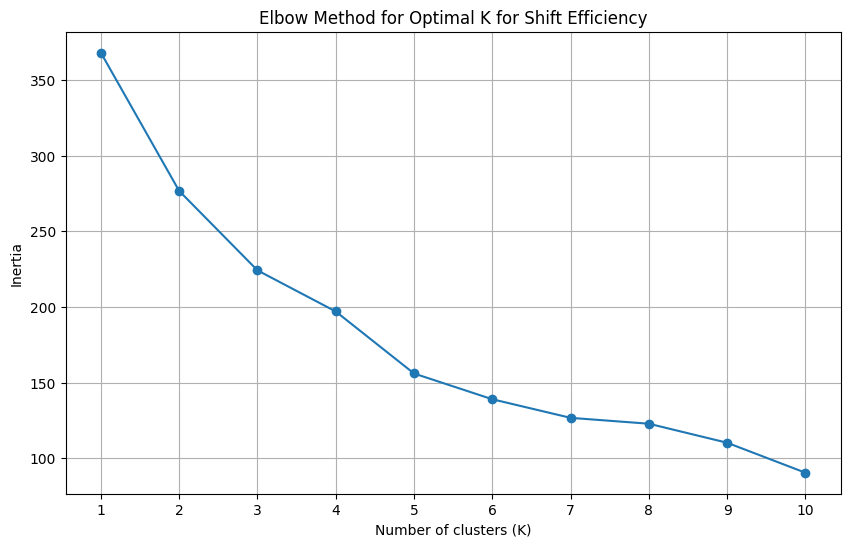

In [80]:
inertia = []

K_range = range(1,11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_shift_aggregated[efficiency_score_cols])
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K for Shift Efficiency')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True)
plt.show()

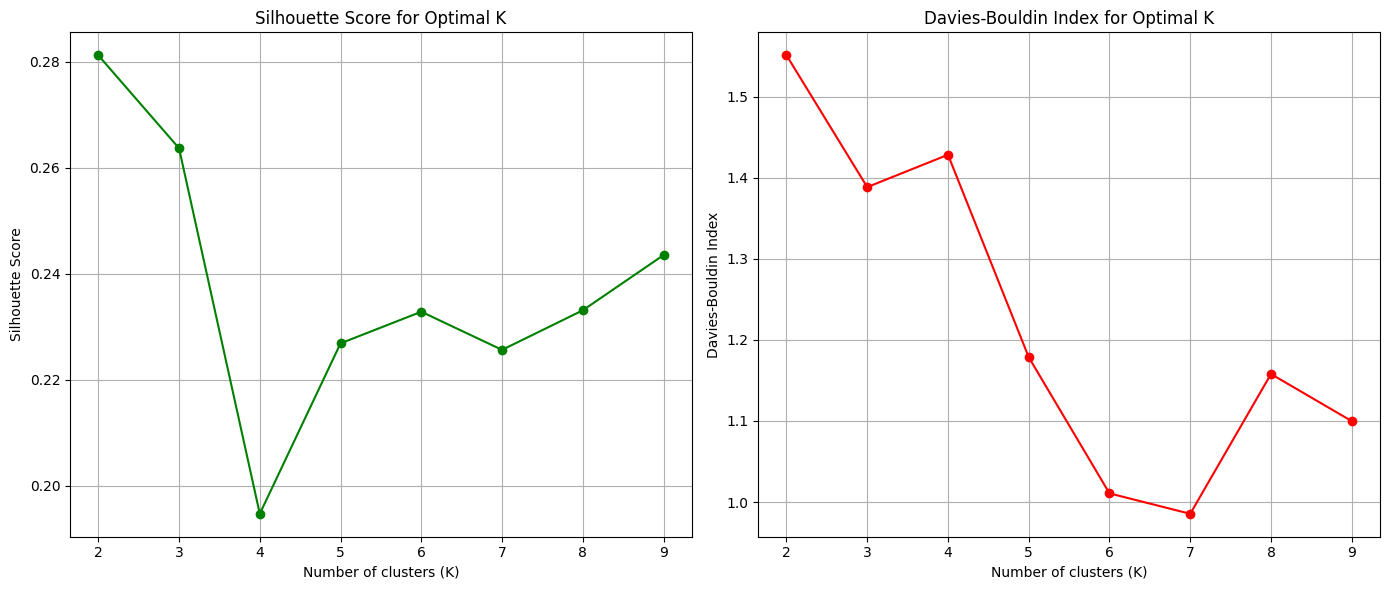

Silhouette Scores: [np.float64(0.28126584198296883), np.float64(0.26372026333897913), np.float64(0.19475202168456268), np.float64(0.22691021248572812), np.float64(0.23287554984985992), np.float64(0.2256795914379269), np.float64(0.23314501090610448), np.float64(0.24356290344594705)]
Davies-Bouldin Indices: [np.float64(1.551267122866214), np.float64(1.3885839396184962), np.float64(1.4285013624511684), np.float64(1.178701590911139), np.float64(1.0106875094412884), np.float64(0.9854924933487393), np.float64(1.1579550652228532), np.float64(1.0998601107374606)]


In [81]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

k_range_eval = range(2, 10)  # Try K from 2 to 9 for evaluation metrics
silhouette_scores = []
davies_bouldin_scores = []

for k in k_range_eval:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(df_shift_aggregated[efficiency_score_cols])

    sil_avg = silhouette_score(df_shift_aggregated[efficiency_score_cols], labels)
    db_idx = davies_bouldin_score(df_shift_aggregated[efficiency_score_cols], labels)

    silhouette_scores.append(sil_avg)
    davies_bouldin_scores.append(db_idx)

# Plotting Silhouette Score and Davies-Bouldin Index
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(k_range_eval, silhouette_scores, marker='o', color='green')
axes[0].set_title('Silhouette Score for Optimal K')
axes[0].set_xlabel('Number of clusters (K)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_xticks(k_range_eval)
axes[0].grid(True)

axes[1].plot(k_range_eval, davies_bouldin_scores, marker='o', color='red')
axes[1].set_title('Davies-Bouldin Index for Optimal K')
axes[1].set_xlabel('Number of clusters (K)')
axes[1].set_ylabel('Davies-Bouldin Index')
axes[1].set_xticks(k_range_eval)
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Print the scores for detailed inspection
print("Silhouette Scores:", silhouette_scores)
print("Davies-Bouldin Indices:", davies_bouldin_scores)

In [82]:
optimal_k_shift = 2 # based on evaluation score

kmeans_optimal_shift = KMeans(n_clusters=optimal_k_shift, random_state=42, n_init='auto')

df_shift_aggregated['shift_efficiency_cluster'] = kmeans_optimal_shift.fit_predict(df_shift_aggregated[efficiency_score_cols])

# Display the first few rows with the new cluster labels
print("DataFrame with new 'shift_efficiency_cluster' column:")
print(df_shift_aggregated[['shift_instance_id', 'machine_id', 'line_id'] + efficiency_score_cols + ['shift_efficiency_cluster']].head())

# Display the count of observations in each cluster
print("\nDistribution of Shift Efficiency Clusters:")
print(df_shift_aggregated['shift_efficiency_cluster'].value_counts().sort_index())


temp_df_original_metrics = df_shift_aggregated[['shift_instance_id', 'machine_id', 'line_id', 'units_produced', 'downtime', 'error_rate', 'cycle_time']].copy()
temp_df_original_metrics['shift_efficiency_cluster'] = df_shift_aggregated['shift_efficiency_cluster']

cluster_centroids_shift = temp_df_original_metrics.groupby('shift_efficiency_cluster')[['units_produced', 'downtime', 'error_rate', 'cycle_time']].mean()
print("\nCluster Centroids (Average Characteristics of Each Shift Efficiency Cluster - Original Values):")
print(cluster_centroids_shift)

DataFrame with new 'shift_efficiency_cluster' column:
         shift_instance_id machine_id line_id  efficiency_error_rate  \
0  2025-03-10_Shift_1_Pagi       M001      L1               0.730918   
1  2025-03-10_Shift_1_Pagi       M002      L2               0.631588   
2  2025-03-10_Shift_1_Pagi       M003      L3              -0.100771   
3  2025-03-10_Shift_1_Pagi       M004      L1               1.053099   
4  2025-03-10_Shift_2_Sore       M001      L1              -0.428642   

   efficiency_downtime  efficiency_cycle_time  efficiency_units_produced  \
0            -0.535504               0.816827                  -0.010710   
1            -0.319588               0.466573                  -1.652865   
2            -0.074603               0.422052                   0.481937   
3            -0.828211              -0.899248                  -0.174925   
4            -0.806661              -0.819586                   0.481937   

   shift_efficiency_cluster  
0                         

## Data Analysis Key Findings (Shift Efficiency Clusters)

*   **Cluster 0 (Higher Efficiency Shifts)**:
    *   **Average Units Produced**: Approximately 33.17 units, significantly higher than Cluster 1.
    *   **Average Downtime**: Approximately 1077.57 minutes (per shift instance), higher than Cluster 1.
    *   **Average Error Rate**: Approximately 0.8013.
    *   **Average Cycle Time**: Approximately 119.97 seconds.
    *   **Interpretation**: This cluster represents shifts with higher overall production output. While they experience considerable downtime, their `units_produced` is much higher, suggesting that when they are operational, they are highly productive. The higher downtime might be associated with more intensive, high-output operations or perhaps more incidents due to greater activity.

*   **Cluster 1 (Lower Efficiency Shifts)**:
    *   **Average Units Produced**: Approximately 14.12 units, significantly lower than Cluster 0.
    *   **Average Downtime**: Approximately 684.07 minutes (per shift instance), lower than Cluster 0.
    *   **Average Error Rate**: Approximately 0.8083, slightly higher than Cluster 0.
    *   **Average Cycle Time**: Approximately 120.25 seconds.
    *   **Interpretation**: This cluster represents shifts with lower production output and also lower downtime compared to Cluster 0. The combination of lower units produced and slightly higher error rates, even with less downtime, indicates a less efficient operational state. These shifts might be experiencing more frequent minor issues that don't lead to long downtimes but impede production, or they might be operating at a lower capacity.

In [88]:
df = df.merge(
    df_shift_aggregated[['shift_instance_id', 'machine_id', 'line_id', 'shift_efficiency_cluster']],
    on=['shift_instance_id', 'machine_id', 'line_id'], how='left'
)






print(df[['shift_instance_id', 'machine_id', 'line_id', 'shift_efficiency_cluster']].head())

         shift_instance_id machine_id line_id  shift_efficiency_cluster
0  2025-03-10_Shift_1_Pagi       M003      L3                         0
1  2025-03-10_Shift_1_Pagi       M004      L1                         0
2  2025-03-10_Shift_1_Pagi       M001      L1                         0
3  2025-03-10_Shift_1_Pagi       M003      L3                         0
4  2025-03-10_Shift_1_Pagi       M003      L3                         0


# Finding Bottlenecks

In [89]:
total_downtime_per_line = df.groupby('line_id')['downtime'].sum()
downtime_frequency_per_line = df.groupby('line_id')['downtime'].apply(lambda x: (x > 0).sum())
avg_error_rate_per_line = df.groupby('line_id')['error_rate'].mean()
total_units_produced_per_line = df.groupby('line_id')['units_produced'].sum()

print("\nTotal Downtime per Line (minutes/hour):\n", total_downtime_per_line)
print("\nDowntime Frequency per Line (number of occurrences):\n", downtime_frequency_per_line)
print("\nAverage Error Rate per Line:\n", avg_error_rate_per_line)
print("\nTotal Units Produced per Line:\n", total_units_produced_per_line)



Total Downtime per Line (minutes/hour):
 line_id
L1    47347.5
L2    17725.5
L3    20684.5
Name: downtime, dtype: float64

Downtime Frequency per Line (number of occurrences):
 line_id
L1    1758
L2     657
L3     789
Name: downtime, dtype: int64

Average Error Rate per Line:
 line_id
L1    0.806368
L2    0.804251
L3    0.798741
Name: error_rate, dtype: float64

Total Units Produced per Line:
 line_id
L1    1311
L2     256
L3     837
Name: units_produced, dtype: int64


In [90]:
# Consolidate findings to identify bottlenecks

print("\n--- Bottleneck Analysis ---")
print("\n1. Machine-level Bottlenecks:")
print("   - Machine M001 has the highest total downtime (25861.5) and highest downtime frequency (960 occurrences), indicating it is the most problematic machine.\n")

print("2. Shift-level Bottlenecks:")
print("   - Cluster 1 represents 'Lower Efficiency Shifts' with significantly lower units produced (14.12 vs 33.17) and slightly higher error rates (0.8083 vs 0.8013), suggesting these shifts are less efficient, even with lower downtime. This could indicate frequent minor issues or lower capacity utilization within these shifts.\n")




--- Bottleneck Analysis ---

1. Machine-level Bottlenecks:
   - Machine M001 has the highest total downtime (25861.5) and highest downtime frequency (960 occurrences), indicating it is the most problematic machine.

2. Shift-level Bottlenecks:
   - Cluster 1 represents 'Lower Efficiency Shifts' with significantly lower units produced (14.12 vs 33.17) and slightly higher error rates (0.8083 vs 0.8013), suggesting these shifts are less efficient, even with lower downtime. This could indicate frequent minor issues or lower capacity utilization within these shifts.



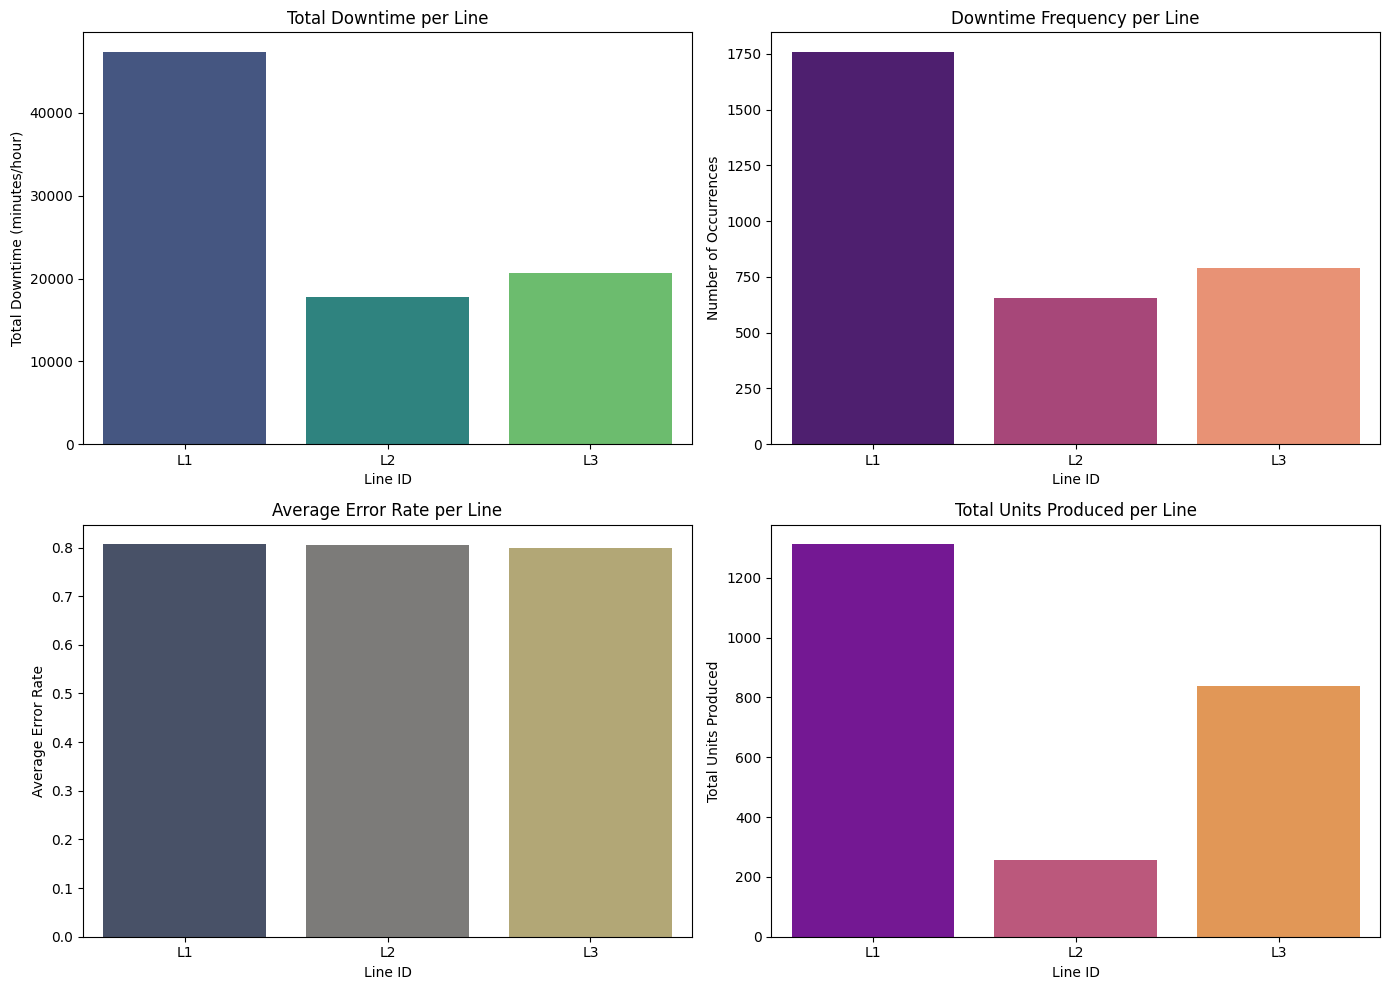

In [91]:
# Create a figure with subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

# Plot Total Downtime per Line
sns.barplot(x=total_downtime_per_line.index, y=total_downtime_per_line.values, ax=axes[0], palette='viridis')
axes[0].set_title('Total Downtime per Line')
axes[0].set_xlabel('Line ID')
axes[0].set_ylabel('Total Downtime (minutes/hour)')

# Plot Downtime Frequency per Line
sns.barplot(x=downtime_frequency_per_line.index, y=downtime_frequency_per_line.values, ax=axes[1], palette='magma')
axes[1].set_title('Downtime Frequency per Line')
axes[1].set_xlabel('Line ID')
axes[1].set_ylabel('Number of Occurrences')

# Plot Average Error Rate per Line
sns.barplot(x=avg_error_rate_per_line.index, y=avg_error_rate_per_line.values, ax=axes[2], palette='cividis')
axes[2].set_title('Average Error Rate per Line')
axes[2].set_xlabel('Line ID')
axes[2].set_ylabel('Average Error Rate')

# Plot Total Units Produced per Line
sns.barplot(x=total_units_produced_per_line.index, y=total_units_produced_per_line.values, ax=axes[3], palette='plasma')
axes[3].set_title('Total Units Produced per Line')
axes[3].set_xlabel('Line ID')
axes[3].set_ylabel('Total Units Produced')

plt.tight_layout()
plt.show()

Total Defect Count per Product Type:
 product_type
Shaft      456
Bracket    298
Gear       168
Flange      55
Housing     52
Name: defect_count, dtype: int64


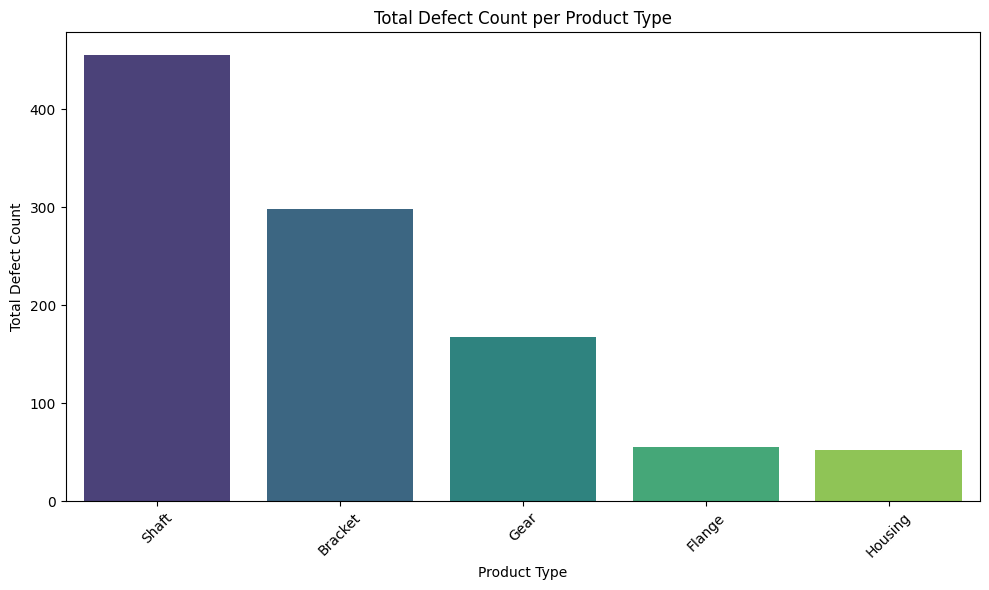

In [92]:
defect_count_per_product_type = df.groupby('product_type')['defect_count'].sum().sort_values(ascending=False)
print("Total Defect Count per Product Type:\n", defect_count_per_product_type)

plt.figure(figsize=(10, 6))
sns.barplot(x=defect_count_per_product_type.index, y=defect_count_per_product_type.values, palette='viridis')
plt.title('Total Defect Count per Product Type')
plt.xlabel('Product Type')
plt.ylabel('Total Defect Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Total units produced: 2404
Good units produced: 1375
Defective units produced: 1029

Percentage of Good Units: 57.20%
Percentage of Defective Units: 42.80%


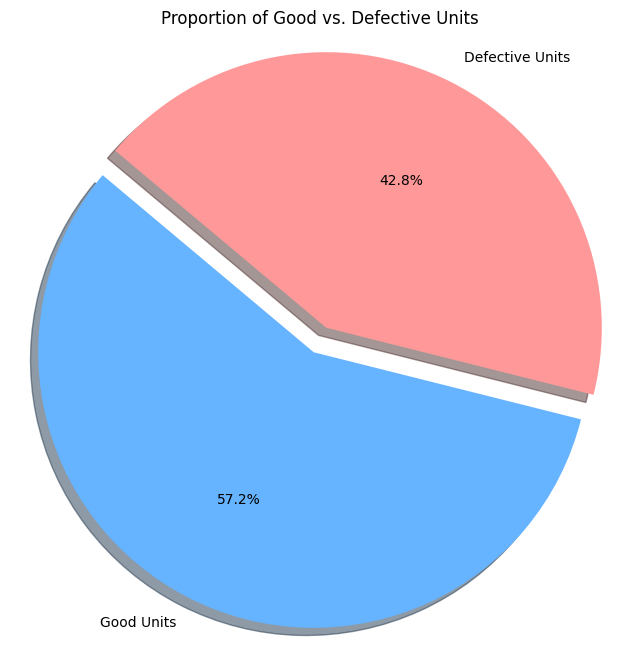

In [93]:
print(f"Total units produced: {total_units_produced}")
print(f"Good units produced: {good_count}")
print(f"Defective units produced: {total_defect_count}")

total_produced_percent = 100
good_percent = (good_count / total_units_produced) * 100
defect_percent = (total_defect_count / total_units_produced) * 100

print(f"\nPercentage of Good Units: {good_percent:.2f}%")
print(f"Percentage of Defective Units: {defect_percent:.2f}%")

# Prepare data for pie chart
labels = ['Good Units', 'Defective Units']
sizes = [good_count, total_defect_count]
colors = ['#66b3ff','#ff9999']
explode = (0.1, 0)  # explode 1st slice (Good Units)

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Proportion of Good vs. Defective Units')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

Defect Percentage per Product Type:
 product_type
Shaft      18.97
Bracket    12.40
Gear        6.99
Flange      2.29
Housing     2.16
Name: defect_count, dtype: float64


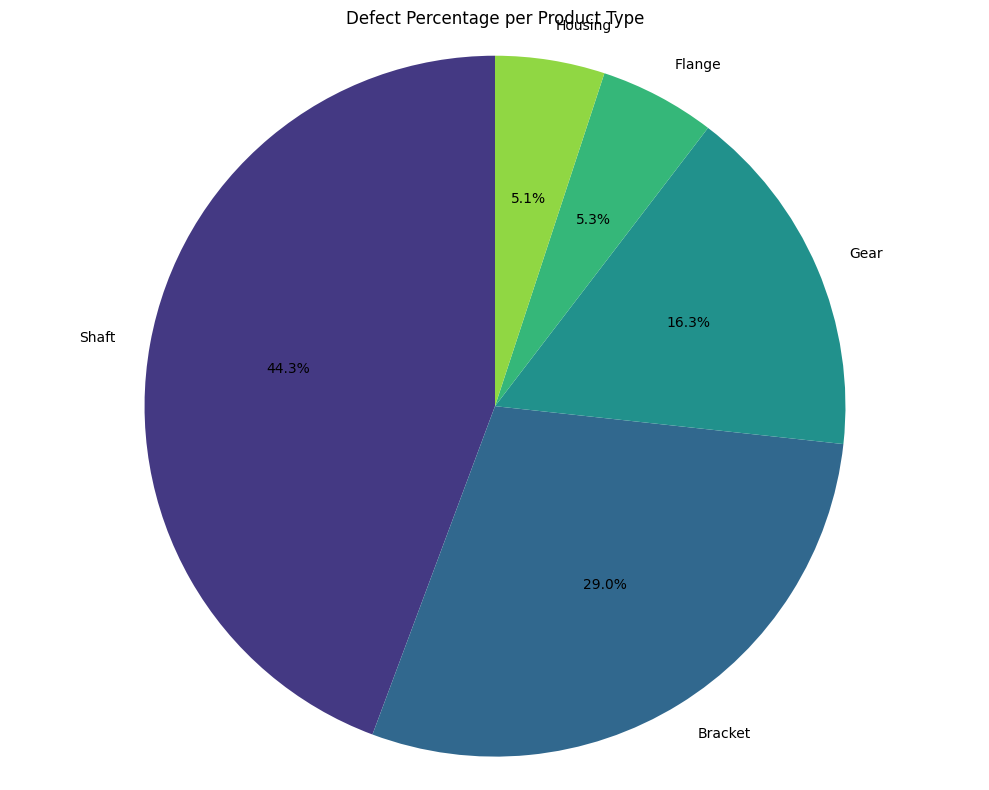

In [94]:
defect_percentage_per_product_type = (defect_count_per_product_type / total_units_produced) * 100
print("Defect Percentage per Product Type:\n", defect_percentage_per_product_type.round(2))

# Plotting the pie chart for defect percentages
plt.figure(figsize=(10, 8))
plt.pie(
    defect_percentage_per_product_type,
    labels=defect_percentage_per_product_type.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('viridis', len(defect_percentage_per_product_type))
)
plt.title('Defect Percentage per Product Type')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

Average Defect Rate by Machine Type:
 machine_type
Drill     0.145044
Lathe     0.110700
CNC       0.106856
Welder    0.044087
Name: defect_count, dtype: float64

Average Defect Rate by Machine ID:
 machine_id
M003    0.145044
M004    0.110700
M001    0.106856
M002    0.044087
Name: defect_count, dtype: float64

Average Defect Rate by Lubrication Status:
 lubrication_status
Good        0.133726
Low         0.100651
Critical    0.044087
Name: defect_count, dtype: float64

Average Defect Rate by Machine Condition Cluster:
 cluster_efficiency_machine
2    0.132809
1    0.081342
0    0.023324
Name: defect_count, dtype: float64

Average Defect Rate by Shift Efficiency Cluster:
 shift_efficiency_cluster
0    0.118903
1    0.065059
Name: defect_count, dtype: float64


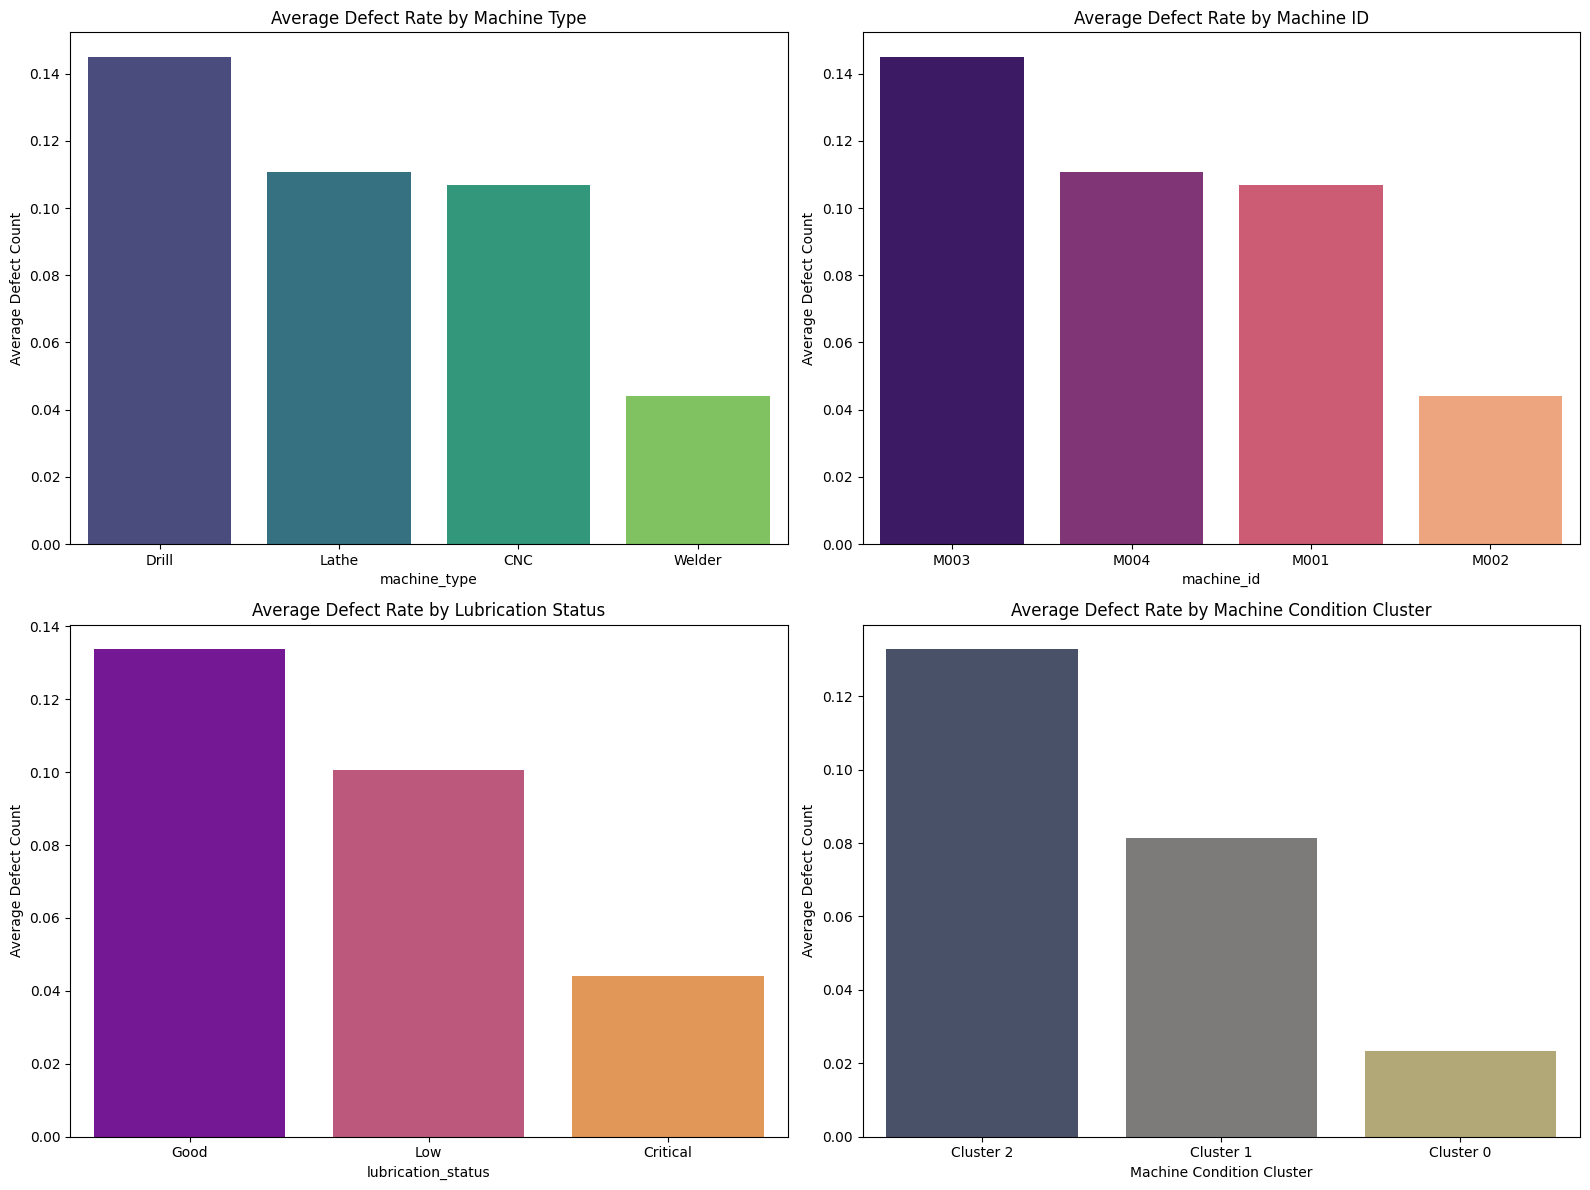

In [95]:
# Defect rate by Machine Type
defect_rate_by_machine_type = df.groupby('machine_type')['defect_count'].mean().sort_values(ascending=False)
print("Average Defect Rate by Machine Type:\n", defect_rate_by_machine_type)

# Defect rate by Machine ID
defect_rate_by_machine_id = df.groupby('machine_id')['defect_count'].mean().sort_values(ascending=False)
print("\nAverage Defect Rate by Machine ID:\n", defect_rate_by_machine_id)

# Defect rate by Lubrication Status
defect_rate_by_lubrication_status = df.groupby('lubrication_status')['defect_count'].mean().sort_values(ascending=False)
print("\nAverage Defect Rate by Lubrication Status:\n", defect_rate_by_lubrication_status)

# Defect rate by Machine Condition Cluster
defect_rate_by_machine_cluster = df.groupby('cluster_efficiency_machine')['defect_count'].mean().sort_values(ascending=False)
print("\nAverage Defect Rate by Machine Condition Cluster:\n", defect_rate_by_machine_cluster)

# Defect rate by Shift Efficiency Cluster
defect_rate_by_shift_cluster = df.groupby('shift_efficiency_cluster')['defect_count'].mean().sort_values(ascending=False)
print("\nAverage Defect Rate by Shift Efficiency Cluster:\n", defect_rate_by_shift_cluster)

# Visualize top factors for defect rates
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

sns.barplot(x=defect_rate_by_machine_type.index, y=defect_rate_by_machine_type.values, ax=axes[0], palette='viridis')
axes[0].set_title('Average Defect Rate by Machine Type')
axes[0].set_ylabel('Average Defect Count')

sns.barplot(x=defect_rate_by_machine_id.index, y=defect_rate_by_machine_id.values, ax=axes[1], palette='magma')
axes[1].set_title('Average Defect Rate by Machine ID')
axes[1].set_ylabel('Average Defect Count')

sns.barplot(x=defect_rate_by_lubrication_status.index, y=defect_rate_by_lubrication_status.values, ax=axes[2], palette='plasma')
axes[2].set_title('Average Defect Rate by Lubrication Status')
axes[2].set_ylabel('Average Defect Count')

sns.barplot(x=defect_rate_by_machine_cluster.index.map(lambda x: f'Cluster {x}'), y=defect_rate_by_machine_cluster.values, ax=axes[3], palette='cividis')
axes[3].set_title('Average Defect Rate by Machine Condition Cluster')
axes[3].set_ylabel('Average Defect Count')
axes[3].set_xlabel('Machine Condition Cluster')

plt.tight_layout()
plt.show()

--- Analyzing the relationship between Temperature, Power Consumption, and Efficiency ---

1. Correlation Analysis with Temperature:
power_consumption    0.263722
error_rate           0.248317
downtime            -0.019847
units_produced      -0.064732
Name: temperature, dtype: float64

2. Simulation of Temperature Impact on Power Consumption and Efficiency Metrics:

Average metrics in LOW Temperature scenario (Temperature <= 75.53°C):
power_consumption    18.290729
error_rate            0.791708
downtime              8.843911
units_produced        0.251488
dtype: float64

Average metrics in NORMAL Temperature scenario (75.53°C < Temperature < 80.87°C):
power_consumption    18.366145
error_rate            0.794129
downtime              8.709268
units_produced        0.251836
dtype: float64

Average metrics in HIGH Temperature scenario (Temperature >= 80.87°C):
power_consumption    19.733497
error_rate            0.835945
downtime              7.765173
units_produced        0.198731
dty

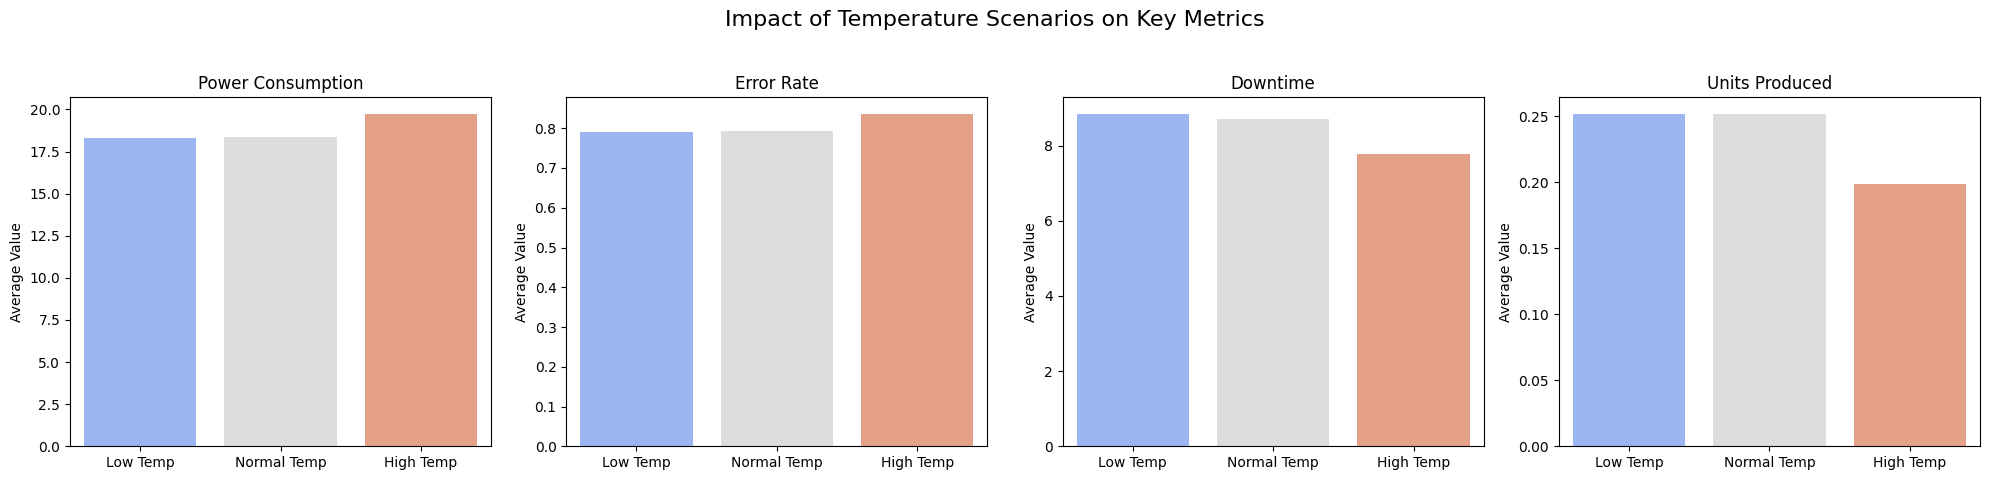

In [96]:
print('--- Analyzing the relationship between Temperature, Power Consumption, and Efficiency ---')

# 1. Calculate correlations with Temperature
print("\n1. Correlation Analysis with Temperature:")
correlation_features = ['temperature', 'power_consumption', 'error_rate', 'downtime', 'units_produced']
correlation_matrix_temp = df[correlation_features].corr()
print(correlation_matrix_temp['temperature'].drop('temperature'))

# 2. Simulate scenarios based on temperature changes
# Define temperature thresholds using quartiles
Q1_temp = df['temperature'].quantile(0.25)
Q3_temp = df['temperature'].quantile(0.75)

# Create scenarios: low temperature, normal temperature, high temperature
df_low_temp = df[df['temperature'] <= Q1_temp]
df_normal_temp = df[(df['temperature'] > Q1_temp) & (df['temperature'] < Q3_temp)]
df_high_temp = df[df['temperature'] >= Q3_temp]

print("\n2. Simulation of Temperature Impact on Power Consumption and Efficiency Metrics:")

# Metrics to compare
metrics_to_compare = ['power_consumption', 'error_rate', 'downtime', 'units_produced']

# Calculate average metrics for each scenario
print("\nAverage metrics in LOW Temperature scenario (Temperature <= {:.2f}°C):".format(Q1_temp))
print(df_low_temp[metrics_to_compare].mean())

print("\nAverage metrics in NORMAL Temperature scenario ({:.2f}°C < Temperature < {:.2f}°C):".format(Q1_temp, Q3_temp))
print(df_normal_temp[metrics_to_compare].mean())

print("\nAverage metrics in HIGH Temperature scenario (Temperature >= {:.2f}°C):".format(Q3_temp))
print(df_high_temp[metrics_to_compare].mean())


# Visualization of the impact
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Impact of Temperature Scenarios on Key Metrics', fontsize=16)

for i, metric in enumerate(metrics_to_compare):
    means = [
        df_low_temp[metric].mean(),
        df_normal_temp[metric].mean(),
        df_high_temp[metric].mean()
    ]
    sns.barplot(x=['Low Temp', 'Normal Temp', 'High Temp'], y=means, ax=axes[i], palette='coolwarm')
    axes[i].set_title(metric.replace('_', ' ').title())
    axes[i].set_ylabel('Average Value')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

1. Correlation Analysis with Temperature:

There's a moderate positive correlation between temperature and power_consumption (0.26) and error_rate (0.25). This suggests that as temperature increases, both power consumption and error rates tend to rise.
There's a very weak negative correlation between temperature and downtime (-0.02) and units_produced (-0.06). This indicates that temperature has a negligible linear relationship with downtime or units produced, or perhaps a non-linear relationship not captured by this metric.
2. Simulation of Temperature Impact on Power Consumption and Efficiency Metrics:

We simulated three temperature scenarios:

Low Temperature (Temperature <= 75.53°C):

Power Consumption: ~18.29 kW
Error Rate: ~0.79
Downtime: ~8.84 minutes
Units Produced: ~0.25 units
Normal Temperature (75.53°C < Temperature < 80.87°C):

Power Consumption: ~18.37 kW
Error Rate: ~0.79
Downtime: ~8.71 minutes
Units Produced: ~0.25 units
High Temperature (Temperature >= 80.87°C):

Power Consumption: ~19.73 kW
Error Rate: ~0.84
Downtime: ~7.77 minutes
Units Produced: ~0.20 units
Interpretation:

The simulation confirms that higher temperatures are associated with increased power consumption and a higher error rate. Conversely, units_produced tends to decrease in high-temperature scenarios, suggesting a drop in productivity. Interestingly, downtime slightly decreases at high temperatures, which might indicate that machines are either shut down quickly due to issues or that these periods are characterized by continuous operation despite other degrading metrics. The visualized bar plots also clearly illustrate these trends, showing a notable jump in power consumption and error rate, and a decrease in units produced when moving from normal to high temperatures.

These findings suggest that maintaining optimal operating temperatures is crucial for minimizing power usage, reducing production errors, and maximizing output.

In [97]:
highest_error_operator = error_per_operator.idxmax()
max_error_rate = error_per_operator.max()

print(f"Operator dengan error rate tertinggi adalah {highest_error_operator} dengan total error rate {max_error_rate:.2f}")

print("\nSemua operator berdasarkan total error rate (dari tertinggi ke terendah):")
print(error_per_operator.sort_values(ascending=False).round(2))

Operator dengan error rate tertinggi adalah OP005 dengan total error rate 0.81

Semua operator berdasarkan total error rate (dari tertinggi ke terendah):
operator_id
OP005    0.81
OP009    0.81
OP006    0.81
OP010    0.81
OP003    0.81
OP011    0.80
OP002    0.80
OP001    0.80
OP004    0.80
OP007    0.80
OP008    0.80
OP012    0.80
Name: error_rate, dtype: float64


In [98]:
print(f"Total units produced: {total_units_produced}")
print(f"Good units produced: {good_count}")
print(f"Defective units produced: {total_defect_count}")

# Overall defect percentage
overall_defect_percentage = (total_defect_count / total_units_produced) * 100
print(f"\nOverall Defect Percentage: {overall_defect_percentage:.2f}%")

# Defect percentage per operator
# First, calculate total defect count per operator
defect_count_per_operator = df.groupby('operator_id')['defect_count'].sum()

# Calculate total units produced per operator
units_produced_per_operator = df.groupby('operator_id')['units_produced'].sum()

# Merge with units_produced_per_operator to get both counts
operator_defect_performance = pd.DataFrame({
    'total_units_produced': units_produced_per_operator,
    'total_defects': defect_count_per_operator
})

# Calculate defect percentage per operator, handling potential division by zero
operator_defect_performance['defect_percentage'] = (
    operator_defect_performance['total_defects'] / operator_defect_performance['total_units_produced']
).fillna(0) * 100

print("\nDefect Percentage per Operator:")
display(operator_defect_performance.sort_values(by='defect_percentage', ascending=False).round(2))

Total units produced: 2404
Good units produced: 1375
Defective units produced: 1029

Overall Defect Percentage: 42.80%

Defect Percentage per Operator:


,total_units_produced,total_defects,defect_percentage
operator_id,,,
OP010,214,99,46.26
OP004,220,99,45.00
OP005,234,105,44.87
OP009,217,97,44.70
OP003,211,93,44.08
OP011,141,62,43.97
OP001,226,99,43.81
OP012,252,110,43.65
OP008,210,91,43.33


In [99]:
df.to_csv('production_data_final.csv', index=False)
df.to_excel('production_data_final.xlsx', index=False)
print("DataFrame saved to 'production_data_final.csv' and 'production_data_final.xlsx'")

DataFrame saved to 'production_data_final.csv' and 'production_data_final.xlsx'
